In [95]:
from pathlib import Path
import os
import re
import math

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import wilcoxon, spearmanr
from scipy.optimize import curve_fit

from pathlib import Path
import sys
import importlib

project_root = Path.cwd().parent

config_path = project_root / "config"
library_path = project_root / "library"

for path in [config_path, library_path]:
    if str(path) not in sys.path:
        sys.path.append(str(path))


import neuprint


import kylie_lib as cl
import lib_compare_receptor_to_neuprint_synapses as connectome
import lib_glucl_drive as glucl

from kylie_lib import syn_specs


In [96]:
results_dir = project_root / "results" / "connectome"
results_dir.mkdir(parents=True, exist_ok=True)

hemibrain_d7_names = pd.read_csv(results_dir / "hemibrainv121_d7_names.csv")
male_d7_names = pd.read_csv(results_dir / "malev09_d7_names.csv")

In [97]:
hemibrain_d7_names.head()

,id,instance,type,status,inputs (#post),outputs (#pre),#voxels
0,911911004,L1L9R8_R,Delta7,Traced,1496,653,1405984537
1,911919917,L1L9R8_R,Delta7,Traced,1182,562,1330959441
2,5813061383,L1L9R8_R,Delta7,Traced,1322,608,1252686779
3,911574261,L1L9R8_R,Delta7,Traced,1283,579,1331108352
4,881221166,L1L9R8_R,Delta7,Traced,1285,606,1392031704


In [98]:
dataset_name = "hemibrainv1.2.1"
# dataset_name = "malev0.9"

data_dir = (
    project_root
    / "results"
    / "connectome"
    / dataset_name
    / "Delta7_per_cell"
)

csv_files = sorted(data_dir.glob("*.csv"))

all_d7_per_cell = {
    f.stem: pd.read_csv(f)
    for f in csv_files}

len(all_d7_per_cell)

42

In [99]:
summary_dir = project_root / "results" / "extracted_signals" / "q_around99"
summary_dir.mkdir(parents=True, exist_ok=True)
summary_df = pd.read_csv(summary_dir / "summary_df.csv")

In [100]:
summary_df

,glomerulus,mean_green,total_green,percentage_total_green,percentage_total_green_divided_by_d7countall,percentage_total_green_divided_by_d7%all,mean_red,total_red,percentage_total_red,percentage_total_red_divided_by_d7countall,percentage_total_red_divided_by_d7%all,total_green_avg,percentage_total_green_avg,percentage_total_green_divided_by_d7countall_avg,percentage_total_green_divided_by_d7%all_avg,total_red_avg,percentage_total_red_avg,percentage_total_red_divided_by_d7countall_avg,percentage_total_red_divided_by_d7%all_avg
0,-4,5860.3,1.128170e+09,6.526031,0.146849,10.137437,17500.1,1.623735e+10,6.730389,0.151447,10.454883,4.700709e+07,0.271918,0.006119,0.422393,6.765564e+08,0.280433,0.006310,0.435620
1,-3,5633.6,1.081626e+09,6.138868,0.131547,9.140853,15844.2,1.550587e+10,6.468171,0.138604,9.631191,4.506776e+07,0.255786,0.005481,0.380869,6.460779e+08,0.269507,0.005775,0.401300
2,-2,5480.3,7.705925e+08,4.261698,0.125829,8.414223,13552.1,1.078569e+10,4.396369,0.129805,8.680115,3.210802e+07,0.177571,0.005243,0.350593,4.494037e+08,0.183182,0.005409,0.361671
3,-1,5240.3,5.205232e+08,2.835668,0.134650,8.475356,12912.1,7.555939e+09,3.006112,0.142744,8.984785,2.168847e+07,0.118153,0.005610,0.353140,3.148308e+08,0.125255,0.005948,0.374366
4,0,6467.2,4.155966e+09,24.000000,0.553998,36.679635,29055.2,5.983264e+10,24.000000,0.553998,36.679635,1.731652e+08,1.000000,0.023083,1.528318,2.493027e+09,1.000000,0.023083,1.528318
5,1,5429.3,4.882501e+08,2.760540,0.130713,8.512495,14139.2,8.720132e+09,3.464934,0.164067,10.684588,2.034375e+07,0.115022,0.005446,0.354687,3.633388e+08,0.144372,0.006836,0.445191
6,2,5972.6,9.532534e+08,5.426323,0.161807,10.935027,16646.4,1.273110e+10,5.100357,0.152087,10.278147,3.971889e+07,0.226097,0.006742,0.455626,5.304625e+08,0.212515,0.006337,0.428256
7,3,6254.2,1.074362e+09,6.332541,0.133685,9.120794,17753.2,1.520261e+10,6.361438,0.134295,9.162414,4.476508e+07,0.263856,0.005570,0.380033,6.334419e+08,0.265060,0.005596,0.381767
8,4,5860.3,1.128170e+09,6.526031,0.146849,10.137437,17500.1,1.623735e+10,6.730389,0.151447,10.454883,4.700709e+07,0.271918,0.006119,0.422393,6.765564e+08,0.280433,0.006310,0.435620


# for each cell, combine all axonal inputs at the axonal glomerulus, and combine all dendritic inputs at all 8 dendritic glomeruli (AL version)

In [7]:
# optional test
target_df = next(df for name, df in all_d7_per_cell.items() if "911578496" in name)
target_df["SynapseCount"].sum()

611

In [8]:
# optional test
target_df_2 = next(df for name, df in all_d7_per_cell.items() if "911578496" in name)
target_df_2.head()

,bodyId_pre,instance_pre,type_pre,SynapseCount
0,910796989,Delta7(PB15)_L5R4_L,Delta7,28
1,911129339,Delta7(PB15)_L4R5_R,Delta7,25
2,880875736,Delta7(PB15)_L5R4_L,Delta7,24
3,911241750,Delta7(PB15)_L6R4_L,Delta7,24
4,910442723,Delta7(PB15)_L4R5_R,Delta7,23


In [9]:
synapse_count_table = glucl.build_synapse_count_table(
    delta_name=hemibrain_d7_names,
    input_dict=all_d7_per_cell,
)

synapse_count_table.head()

,id,instance,total_input,axonal_input,dendritic_input
0,911911004,L1L9R8_R,724,101,623
1,911919917,L1L9R8_R,554,98,456
2,5813061383,L1L9R8_R,644,95,549
3,911574261,L1L9R8_R,593,90,503
4,881221166,L1L9R8_R,611,71,540


In [10]:
check = (synapse_count_table["total_input"] ==
    synapse_count_table["axonal_input"]
    + synapse_count_table["dendritic_input"]
)
check.all()

True

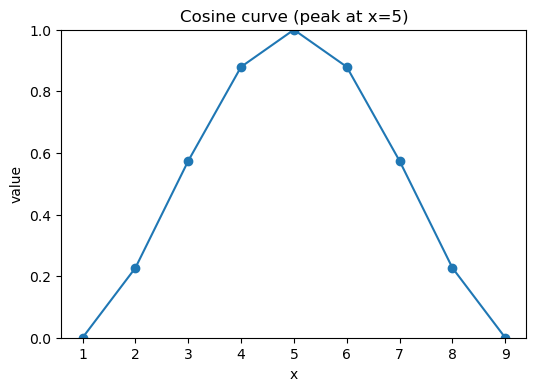

In [11]:
# x from 1 to 9
x = np.arange(1, 10)
# cosine with peak centered at x=5
y_raw = np.cos(2 * np.pi * (x - 5) / 9)
# normalize to range 0 → 1
y = (y_raw - y_raw.min()) / (y_raw.max() - y_raw.min())

plt.figure(figsize=(6, 4))
plt.plot(x,y,marker="o",)
plt.xticks(x)
plt.ylim(0, 1)
plt.xlabel("x")
plt.ylabel("value")
plt.title("Cosine curve (peak at x=5)")

plt.show()

In [12]:
synapse_count_table_add_bump = glucl.add_cosine_bump_columns(
    summary_df=synapse_count_table
)

synapse_count_table_add_bump.head()

,id,instance,total_input,axonal_input,dendritic_input,axon_4_L,axon_3_L,axon_2_L,axon_1_L,axon_0,...,axon_4_R,dendrite_4_L,dendrite_3_L,dendrite_2_L,dendrite_1_L,dendrite_0,dendrite_1_R,dendrite_2_R,dendrite_3_R,dendrite_4_R
0,911911004,L1L9R8_R,724,101,623,0.0,22.894841,57.971773,88.817909,101.0,...,0.0,623.0,531.763762,311.5,91.236238,0.0,91.236238,311.5,531.763762,623.0
1,911919917,L1L9R8_R,554,98,456,0.0,22.214796,56.249839,86.179754,98.0,...,0.0,456.0,389.220346,228.0,66.779654,0.0,66.779654,228.0,389.220346,456.0
2,5813061383,L1L9R8_R,644,95,549,0.0,21.534752,54.527905,83.541598,95.0,...,0.0,549.0,468.600811,274.5,80.399189,0.0,80.399189,274.5,468.600811,549.0
3,911574261,L1L9R8_R,593,90,503,0.0,20.401344,51.658016,79.144672,90.0,...,0.0,503.0,429.337355,251.5,73.662645,0.0,73.662645,251.5,429.337355,503.0
4,881221166,L1L9R8_R,611,71,540,0.0,16.094393,40.752435,62.436352,71.0,...,0.0,540.0,460.918831,270.0,79.081169,0.0,79.081169,270.0,460.918831,540.0


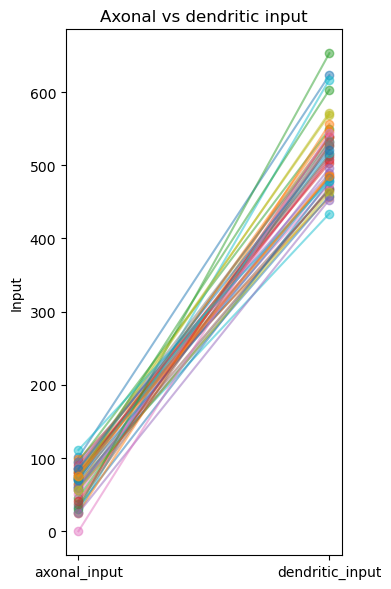

In [13]:
plt.figure(figsize=(4, 6))

x = [0, 1]

for _, row in synapse_count_table_add_bump.iterrows():

    y = [
        row["axonal_input"],
        row["dendritic_input"],
    ]

    plt.plot(
        x,
        y,
        marker="o",
        alpha=0.5,
    )

plt.xticks(
    [0, 1],
    ["axonal_input", "dendritic_input"],
)

plt.ylabel("Input")
plt.title("Axonal vs dendritic input")

plt.tight_layout()
plt.show()

In [14]:
bump_cols = [
    c
    for c in synapse_count_table_add_bump.columns
    if c.startswith("axon_") or c.startswith("dendrite_")]

synapse_count_table_add_bump_summary = pd.DataFrame([synapse_count_table_add_bump[bump_cols].sum()])

synapse_count_table_add_bump_summary.insert(
    0,
    "source",
    "no_glucl_weight_added",)

synapse_count_table_add_bump_summary

,source,axon_4_L,axon_3_L,axon_2_L,axon_1_L,axon_0,axon_1_R,axon_2_R,axon_3_R,axon_4_R,dendrite_4_L,dendrite_3_L,dendrite_2_L,dendrite_1_L,dendrite_0,dendrite_1_R,dendrite_2_R,dendrite_3_R,dendrite_4_R
0,no_glucl_weight_added,0.0,628.361387,1591.066884,2437.65589,2772.0,2437.65589,1591.066884,628.361387,0.0,21704.0,18525.522789,10852.0,3178.477211,0.0,3178.477211,10852.0,18525.522789,21704.0


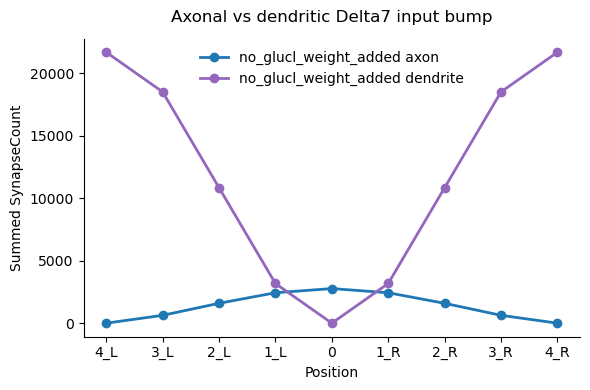

In [15]:
glucl.plot_axon_dendrite_bump_summary(
    synapse_count_table_add_bump_summary,
    title="Axonal vs dendritic Delta7 input bump",
    ylabel="Summed SynapseCount",
    axon_colors="tab:blue",
    dendrite_colors="tab:purple",
    figsize=(6, 4),
    # save_svg=results_dir / dataset_name / "Delta7_per_cell" / "axon_dendrite_bump_summary.svg",
)

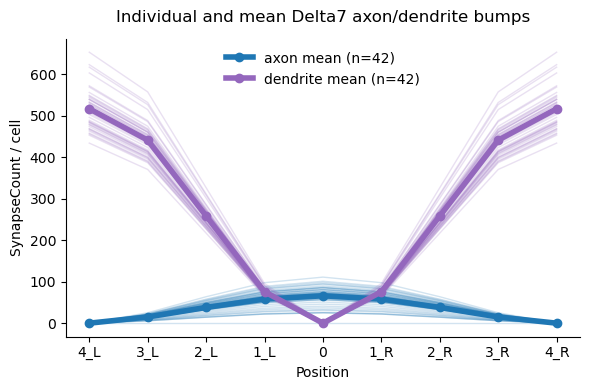

In [16]:
glucl.plot_individual_and_mean_axon_dendrite_bumps(
    individual_df=synapse_count_table_add_bump,
    sum_df=synapse_count_table_add_bump_summary,
    axon_color="tab:blue",
    dendrite_color="tab:purple",
    individual_alpha=0.2,           # lower alpha, more transparent
    mean_linewidth=4,
    ylabel="SynapseCount / cell",
    title="Individual and mean Delta7 axon/dendrite bumps",
    figsize=(6, 4),
    #save_svg=results_dir / dataset_name / "Delta7_per_cell" / "individual_mean_bumps.svg",
)

In [17]:
# get the glucl scaling values for axonal inputs and dendritic inputs

glucl_scaling_values = glucl.compute_glucl_scaling_values(
    summary_df=summary_df,
    divide_by=24,)

glucl_scaling_values

{'percentage_total_green_dendritemean': 0.21254010709238122,
 'percentage_total_green_axon': 1.0,
 'percentage_total_green_divided_by_d7countall_dendritemean': 0.0057912990777446195,
 'percentage_total_green_divided_by_d7countall_axon': 0.023083264633140973}

In [18]:
# directly multiply the glucl_scaling_values to the summary df.
synapse_count_table_add_bump_summary_glucl = (
    glucl.build_multiplied_bump_summary(
        summary_df=summary_df,
        bump_summary_df=synapse_count_table_add_bump_summary,
        divide_by=24,
    ))

synapse_count_table_add_bump_summary_all = pd.concat(
    [synapse_count_table_add_bump_summary, synapse_count_table_add_bump_summary_glucl,],
    ignore_index=True,)
synapse_count_table_add_bump_summary_all

,source,axon_4_L,axon_3_L,axon_2_L,axon_1_L,axon_0,axon_1_R,axon_2_R,axon_3_R,axon_4_R,dendrite_4_L,dendrite_3_L,dendrite_2_L,dendrite_1_L,dendrite_0,dendrite_1_R,dendrite_2_R,dendrite_3_R,dendrite_4_R
0,no_glucl_weight_added,0.0,628.361387,1591.066884,2437.655890,2772.00000,2437.655890,1591.066884,628.361387,0.0,21704.000000,18525.522789,10852.000000,3178.477211,0.0,3178.477211,10852.000000,18525.522789,21704.000000
1,multiply_percentage_total_green,0.0,628.361387,1591.066884,2437.655890,2772.00000,2437.655890,1591.066884,628.361387,0.0,4612.970484,3937.416598,2306.485242,675.553887,0.0,675.553887,2306.485242,3937.416598,4612.970484
2,multiply_percentage_total_green_divided_by_d7c...,0.0,14.504632,36.727018,56.269056,63.98681,56.269056,36.727018,14.504632,0.0,125.694355,107.286843,62.847178,18.407512,0.0,18.407512,62.847178,107.286843,125.694355


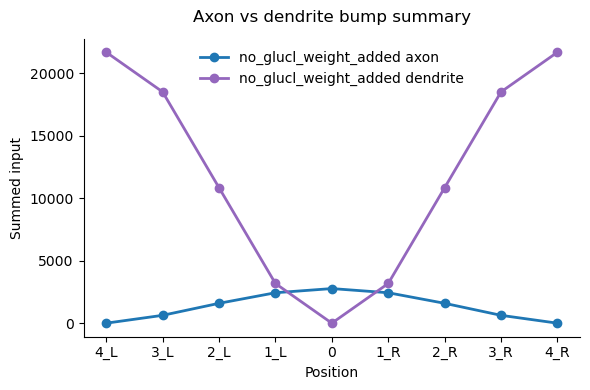

In [19]:
glucl.plot_axon_dendrite_bump_summary(
    synapse_count_table_add_bump_summary_all,
    rows=[0],
    axon_colors=["tab:blue"],
    dendrite_colors=["tab:purple"],
    figsize=(6, 4),
)

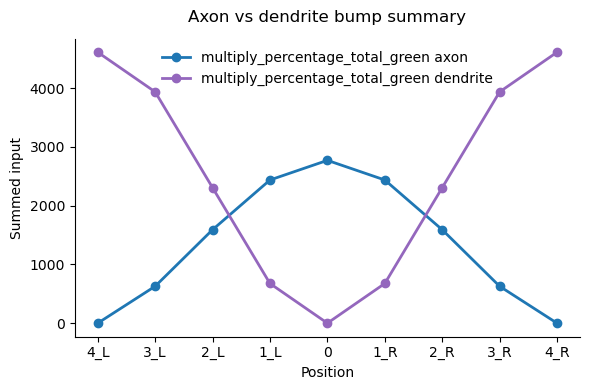

In [20]:
glucl.plot_axon_dendrite_bump_summary(
    synapse_count_table_add_bump_summary_all,
    rows=["multiply_percentage_total_green"],
    axon_colors="tab:blue",
    dendrite_colors="tab:purple",
    figsize=(6, 4),
)

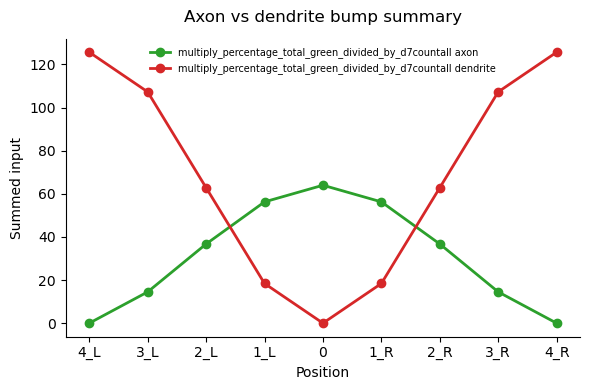

In [21]:
glucl.plot_axon_dendrite_bump_summary(
    synapse_count_table_add_bump_summary_all,
    rows=[2],
    axon_colors=["tab:green"],
    dendrite_colors=["tab:red"],
    figsize=(6, 4),
    legend_fontsize=7,
)

In [22]:
importlib.reload(glucl)

<module 'lib_glucl_drive' from '/Users/sansachen/Desktop/fisherlab/github-works/connectome_analysis_fisherlab/send_to_fisherlabgithub/library/lib_glucl_drive.py'>

In [23]:
# multiply the glucl_scaling_values to each delta7 neuron first (NOTE: now atotal_input ≠ xonal_input+dendritic_input)
synapse_count_table_add_bump_receptor = (
    glucl.apply_glucl_scaling_to_individual_bumps(
        df=synapse_count_table_add_bump,
        glucl_scaling_values=glucl_scaling_values,
        axon_key="percentage_total_green_axon",
        dendrite_key="percentage_total_green_dendritemean",
    )
)

synapse_count_table_add_bump_receptorbysynapse = (
    glucl.apply_glucl_scaling_to_individual_bumps(
        df=synapse_count_table_add_bump,
        glucl_scaling_values=glucl_scaling_values,
        axon_key="percentage_total_green_divided_by_d7countall_axon",
        dendrite_key="percentage_total_green_divided_by_d7countall_dendritemean",
    )
)

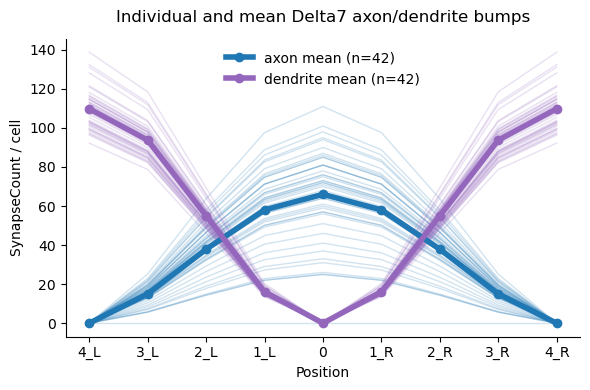

In [24]:
glucl.plot_individual_and_mean_axon_dendrite_bumps(
    individual_df=synapse_count_table_add_bump_receptor,
    sum_df=synapse_count_table_add_bump_summary_all,
    sum_source="multiply_percentage_total_green",
    axon_color="tab:blue",
    dendrite_color="tab:purple",
    individual_alpha=0.2,           # lower alpha, more transparent
    mean_linewidth=4,
    ylabel="SynapseCount / cell",
    title="Individual and mean Delta7 axon/dendrite bumps",
    figsize=(6, 4),
    #save_svg=results_dir / dataset_name / "Delta7_per_cell" / "individual_mean_bumps.svg",
)

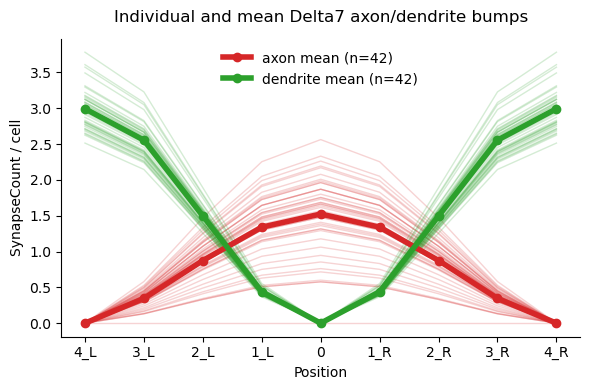

In [25]:
glucl.plot_individual_and_mean_axon_dendrite_bumps(
    individual_df=synapse_count_table_add_bump_receptorbysynapse,
    sum_df=synapse_count_table_add_bump_summary_all,
    sum_source="multiply_percentage_total_green_divided_by_d7countall",
    axon_color="tab:red",
    dendrite_color="tab:green",
    individual_alpha=0.2,           # lower alpha, more transparent
    mean_linewidth=4,
    ylabel="SynapseCount / cell",
    title="Individual and mean Delta7 axon/dendrite bumps",
    figsize=(6, 4),
    #save_svg=results_dir / dataset_name / "Delta7_per_cell" / "individual_mean_bumps.svg",
)

In [26]:
row1 = synapse_count_table_add_bump_summary_all.loc[
    synapse_count_table_add_bump_summary_all["source"]
    == "multiply_percentage_total_green"
].iloc[0]

row2 = synapse_count_table_add_bump_summary_all.loc[
    synapse_count_table_add_bump_summary_all["source"]
    == "multiply_percentage_total_green_divided_by_d7countall"
].iloc[0]

numeric_cols = [
    c for c in synapse_count_table_add_bump_summary_all.columns
    if c != "source"
]

ratio = row2[numeric_cols] / row1[numeric_cols]
ratio

axon_4_L             NaN
axon_3_L        0.023083
axon_2_L        0.023083
axon_1_L        0.023083
axon_0          0.023083
axon_1_R        0.023083
axon_2_R        0.023083
axon_3_R        0.023083
axon_4_R             NaN
dendrite_4_L    0.027248
dendrite_3_L    0.027248
dendrite_2_L    0.027248
dendrite_1_L    0.027248
dendrite_0           NaN
dendrite_1_R    0.027248
dendrite_2_R    0.027248
dendrite_3_R    0.027248
dendrite_4_R    0.027248
dtype: object

# for each cell, don't combine axonal/dendritic inputs (TQ version)

In [27]:
d7_input_matrix = glucl.build_d7_input_matrix(
    delta_name=hemibrain_d7_names,   # or your demibrain_df_names
    input_dict=all_d7_per_cell,)

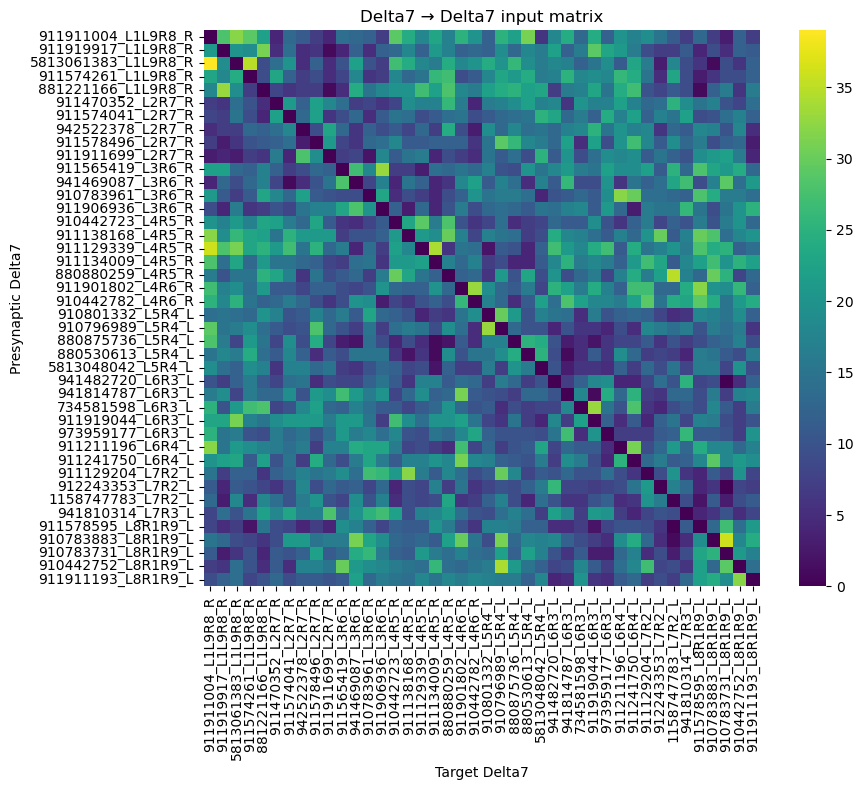

In [28]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    d7_input_matrix,
    cmap="viridis",
    square=True,)

plt.xlabel("Target Delta7")
plt.ylabel("Presynaptic Delta7")
plt.title("Delta7 → Delta7 input matrix")
plt.tight_layout()
plt.show()

In [29]:
d7_relative_glomerulus_matrix = glucl.build_d7_relative_glomerulus_matrix(
    reference_matrix=d7_input_matrix,
    glomerulus_order=["L1", "L2", "L3", "L4", "L5", "L6", "L7", "L8"],)

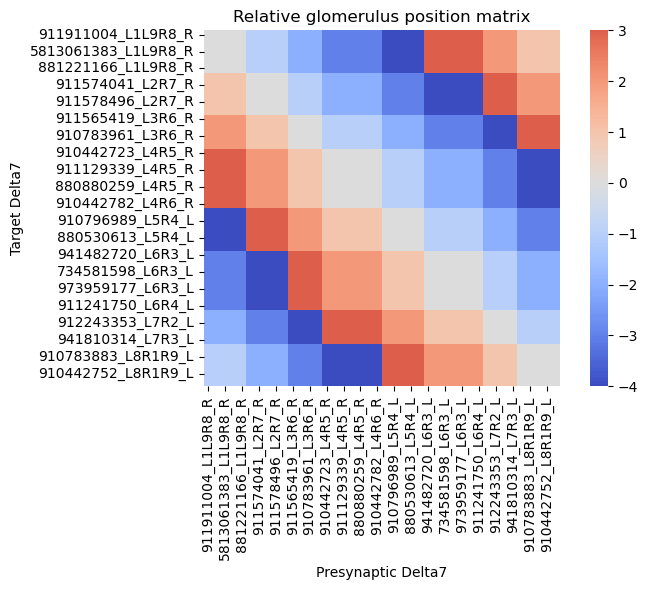

In [30]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    d7_relative_glomerulus_matrix,
    cmap="coolwarm",
    center=0,
    square=True,)
plt.xlabel("Presynaptic Delta7")
plt.ylabel("Target Delta7")
plt.title("Relative glomerulus position matrix")
plt.tight_layout()
plt.show()

In [31]:
d7_glucl_matrix_percentage_total_green = (
    glucl.map_relative_matrix_to_summary_values(
        relative_matrix=d7_relative_glomerulus_matrix,
        summary_df=summary_df,
        value_col="percentage_total_green",
        glomerulus_col="glomerulus",
        drop_glomerulus=4,
    )
)

/Users/sansachen/Desktop/fisherlab/github-works/connectome_analysis_fisherlab/send_to_fisherlabgithub/library/lib_glucl_drive.py:941: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  out = out.applymap(lambda x: value_map.get(x, np.nan))


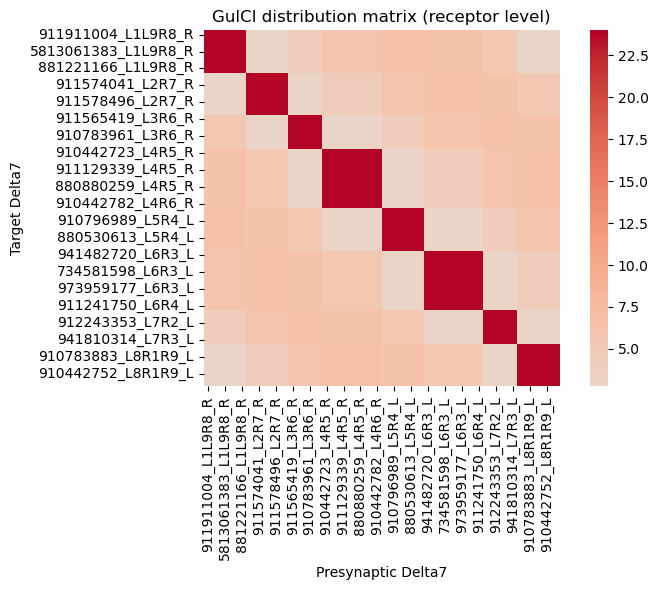

In [32]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    d7_glucl_matrix_percentage_total_green,
    cmap="coolwarm",
    center=0,
    square=True,)
plt.xlabel("Presynaptic Delta7")
plt.ylabel("Target Delta7")
plt.title("GulCl distribution matrix (receptor level)")
plt.tight_layout()
plt.show()

In [33]:
d7_glucl_matrix_d7norm = (
    glucl.map_relative_matrix_to_summary_values(
        relative_matrix=d7_relative_glomerulus_matrix,
        summary_df=summary_df,
        value_col="percentage_total_green_divided_by_d7countall",
        glomerulus_col="glomerulus",
        drop_glomerulus=4,
    )
)

/Users/sansachen/Desktop/fisherlab/github-works/connectome_analysis_fisherlab/send_to_fisherlabgithub/library/lib_glucl_drive.py:941: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  out = out.applymap(lambda x: value_map.get(x, np.nan))


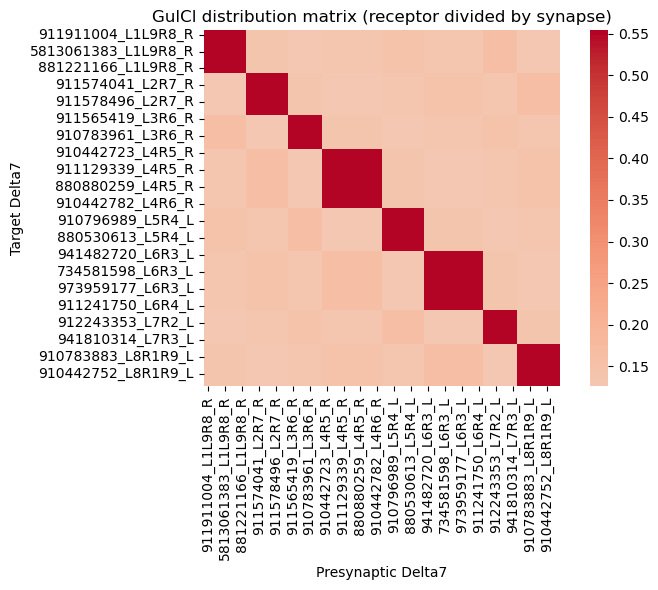

In [34]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    d7_glucl_matrix_d7norm,
    cmap="coolwarm",
    center=0,
    square=True,)
plt.xlabel("Presynaptic Delta7")
plt.ylabel("Target Delta7")
plt.title("GulCl distribution matrix (receptor divided by synapse)")
plt.tight_layout()
plt.show()

In [35]:
# add the glucl receptor distribution into the synapse count matrix
d7_input_matrix_glucl_receptor = (d7_input_matrix * d7_glucl_matrix_percentage_total_green)

d7_input_matrix_glucl_receptor_by_synapse = (d7_input_matrix * d7_glucl_matrix_d7norm)

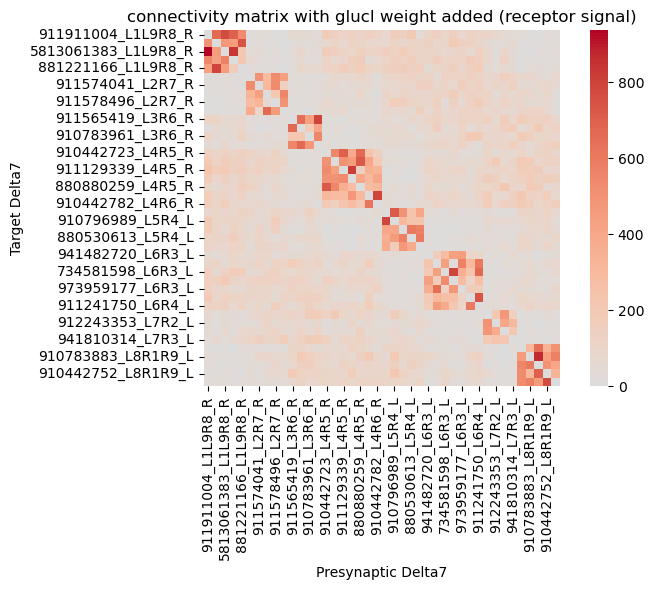

In [94]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    d7_input_matrix_glucl_receptor,
    cmap="coolwarm",
    center=0,
    square=True,)
plt.xlabel("Presynaptic Delta7")
plt.ylabel("Target Delta7")
plt.title("connectivity matrix with glucl weight added (receptor signal)")
plt.tight_layout()
plt.show()

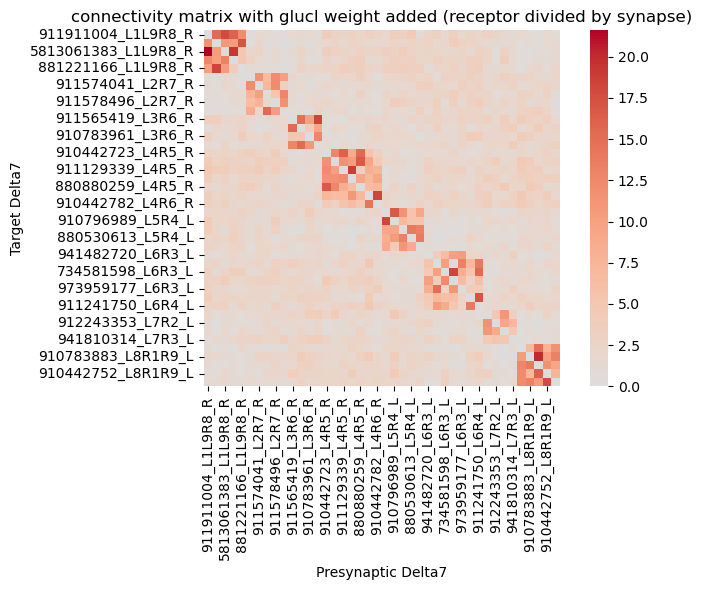

In [37]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    d7_input_matrix_glucl_receptor_by_synapse,
    cmap="coolwarm",
    center=0,
    square=True,)
plt.xlabel("Presynaptic Delta7")
plt.ylabel("Target Delta7")
plt.title("connectivity matrix with glucl weight added (receptor divided by synapse)")
plt.tight_layout()
plt.show()

# run a bump through the connectivity matrix with glucl level added in

Cosine bump values:
[1.    0.854 0.5   0.146 0.    0.146 0.5   0.854]


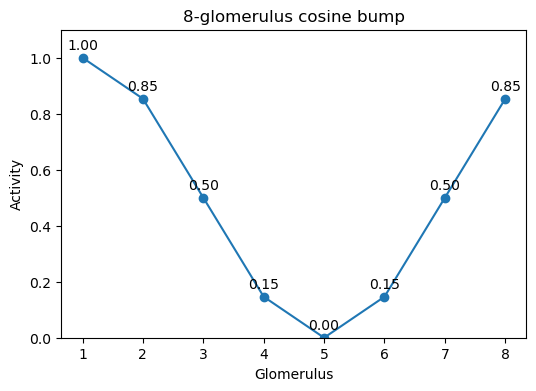

In [38]:
# make a cosine bump with T=8 (8 glomeruli). endpoint should be True because glomerulu 1 and 8 represent different angles
# verified by Cheng lyu 2022 Extended Data Fig.5d

n_gloms = 8
theta = np.linspace(0, 2*np.pi, n_gloms, endpoint=False)
# just label them 1~8
x = np.arange(1, n_gloms + 1)


center = 0  # bump center angle
cos_raw = np.cos(theta - center)

# normalize to 0~1
cos_bump = (cos_raw - cos_raw.min()) / (cos_raw.max() - cos_raw.min())  #<-- this is an array

print("Cosine bump values:")
print(np.round(cos_bump, 3))

plt.figure(figsize=(6,4))
plt.plot(
    x,
    cos_bump,
    marker="o",)
# show values on plot
for xi, yi in zip(x, cos_bump):
    plt.text(
        xi,
        yi + 0.03,
        f"{yi:.2f}",
        ha="center",)
plt.xticks(x)
plt.ylim(0, 1.1)
plt.xlabel("Glomerulus")
plt.ylabel("Activity")
plt.title("8-glomerulus cosine bump")
plt.show()


Von Mises bump values:
[1.    0.557 0.135 0.033 0.018 0.033 0.135 0.557]


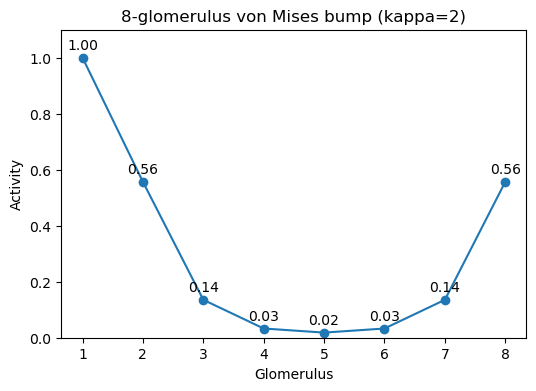

In [39]:
# make a von mises bump

kappa = 2  # larger = sharper bump

vm_raw = np.exp(kappa * np.cos(theta - center))

# normalize to 0~1
vm_bump = vm_raw / vm_raw.max()

print("\nVon Mises bump values:")
print(np.round(vm_bump, 3))

plt.figure(figsize=(6,4))
plt.plot(
    x,
    vm_bump,
    marker="o",)
# show values on plot
for xi, yi in zip(x, vm_bump):
    plt.text(
        xi,
        yi + 0.03,
        f"{yi:.2f}",
        ha="center",)
plt.xticks(x)
plt.ylim(0, 1.1)
plt.xlabel("Glomerulus")
plt.ylabel("Activity")
plt.title(f"8-glomerulus von Mises bump (kappa={kappa})")
plt.show()

In [40]:
cos_bump

array([1.        , 0.85355339, 0.5       , 0.14644661, 0.        ,
       0.14644661, 0.5       , 0.85355339])

In [61]:
vm_bump

array([1.        , 0.55666791, 0.13533528, 0.03290227, 0.01831564,
       0.03290227, 0.13533528, 0.55666791])

In [64]:
delta_bump = np.array([1, 0, 0, 0, 0, 0, 0, 0])
delta_bump

array([1, 0, 0, 0, 0, 0, 0, 0])

In [41]:
d7_bump_locations = glucl.map_relative_matrix_to_cosine_bump(
    relative_matrix=d7_relative_glomerulus_matrix,
    cos_bump_array=cos_bump,
)

d7_bump_locations.head()

/Users/sansachen/Desktop/fisherlab/github-works/connectome_analysis_fisherlab/send_to_fisherlabgithub/library/lib_glucl_drive.py:991: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  out = out.applymap(lambda x: relative_to_bump.get(int(x), np.nan))


,911911004_L1L9R8_R,911919917_L1L9R8_R,5813061383_L1L9R8_R,911574261_L1L9R8_R,881221166_L1L9R8_R,911470352_L2R7_R,911574041_L2R7_R,942522378_L2R7_R,911578496_L2R7_R,911911699_L2R7_R,...,911241750_L6R4_L,911129204_L7R2_L,912243353_L7R2_L,1158747783_L7R2_L,941810314_L7R3_L,911578595_L8R1R9_L,910783883_L8R1R9_L,910783731_L8R1R9_L,910442752_L8R1R9_L,911911193_L8R1R9_L
911911004_L1L9R8_R,1.0,1.0,1.0,1.0,1.0,0.853553,0.853553,0.853553,0.853553,0.853553,...,0.146447,0.5,0.5,0.5,0.5,0.853553,0.853553,0.853553,0.853553,0.853553
911919917_L1L9R8_R,1.0,1.0,1.0,1.0,1.0,0.853553,0.853553,0.853553,0.853553,0.853553,...,0.146447,0.5,0.5,0.5,0.5,0.853553,0.853553,0.853553,0.853553,0.853553
5813061383_L1L9R8_R,1.0,1.0,1.0,1.0,1.0,0.853553,0.853553,0.853553,0.853553,0.853553,...,0.146447,0.5,0.5,0.5,0.5,0.853553,0.853553,0.853553,0.853553,0.853553
911574261_L1L9R8_R,1.0,1.0,1.0,1.0,1.0,0.853553,0.853553,0.853553,0.853553,0.853553,...,0.146447,0.5,0.5,0.5,0.5,0.853553,0.853553,0.853553,0.853553,0.853553
881221166_L1L9R8_R,1.0,1.0,1.0,1.0,1.0,0.853553,0.853553,0.853553,0.853553,0.853553,...,0.146447,0.5,0.5,0.5,0.5,0.853553,0.853553,0.853553,0.853553,0.853553


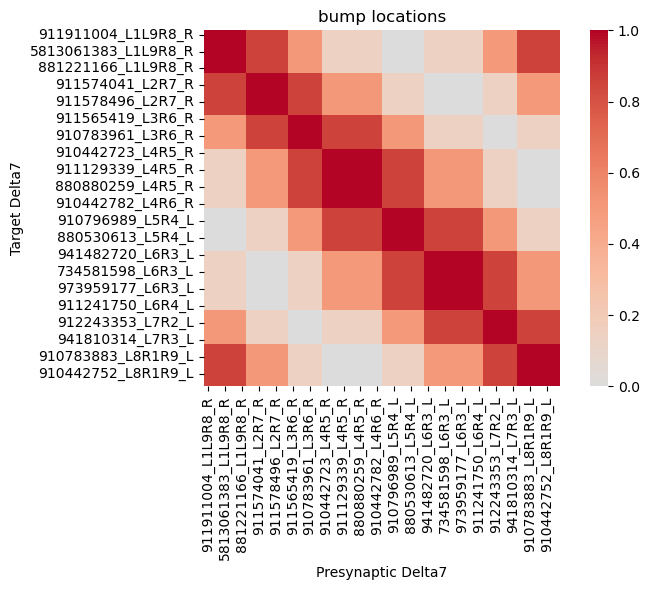

In [42]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    d7_bump_locations,
    cmap="coolwarm",
    center=0,
    square=True,)
plt.xlabel("Presynaptic Delta7")
plt.ylabel("Target Delta7")
plt.title("bump locations")
plt.tight_layout()
plt.show()

In [43]:
# matrix multiplication, @ is equivalent to .dot in np
d7_result_bump_summary = (
    d7_input_matrix_glucl_receptor
    .dot(d7_bump_locations)
)

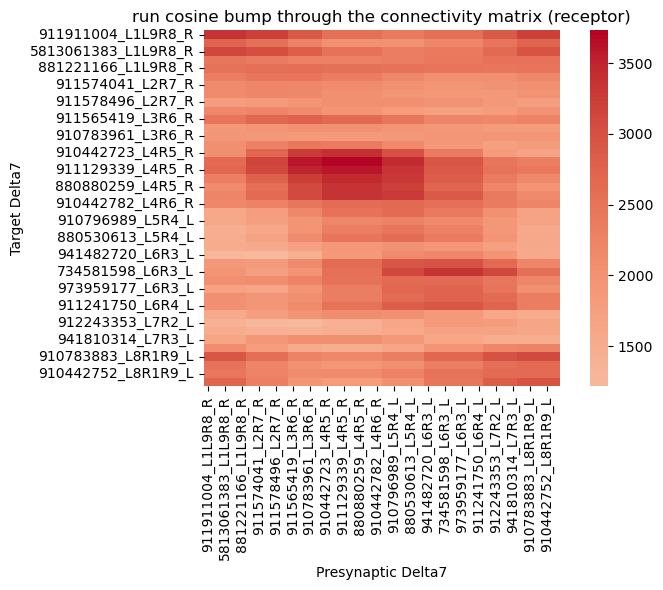

In [44]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    d7_result_bump_summary,
    cmap="coolwarm",
    center=0,
    square=True,)
plt.xlabel("Presynaptic Delta7")
plt.ylabel("Target Delta7")
plt.title("run cosine bump through the connectivity matrix (receptor)")
plt.tight_layout()
plt.show()

In [95]:
d7_result_bump_summary_by_synapse = (
    d7_input_matrix_glucl_receptor_by_synapse
    .dot(d7_bump_locations)
)

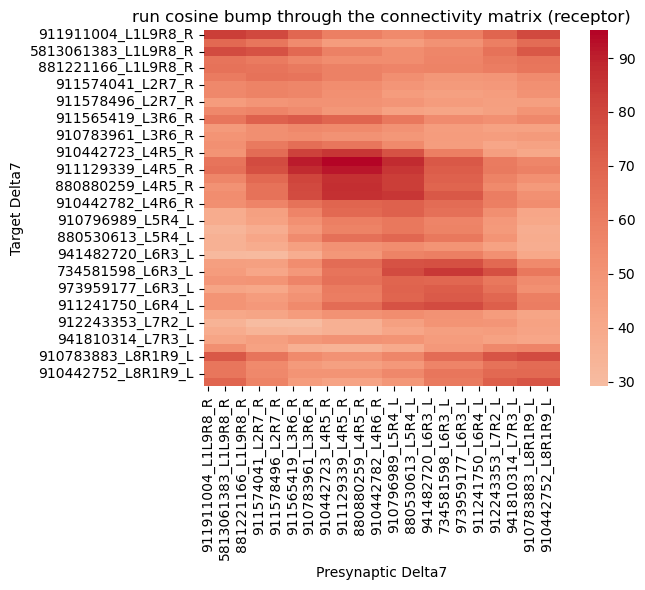

In [96]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    d7_result_bump_summary_by_synapse,
    cmap="coolwarm",
    center=0,
    square=True,)
plt.xlabel("Presynaptic Delta7")
plt.ylabel("Target Delta7")
plt.title("run cosine bump through the connectivity matrix (receptor)")
plt.tight_layout()
plt.show()

In [45]:
d7_result_bump_summary_rolled = glucl.roll_matrix_columns_to_center_zero(
    input_matrix=d7_result_bump_summary,
    relative_matrix=d7_relative_glomerulus_matrix,
)

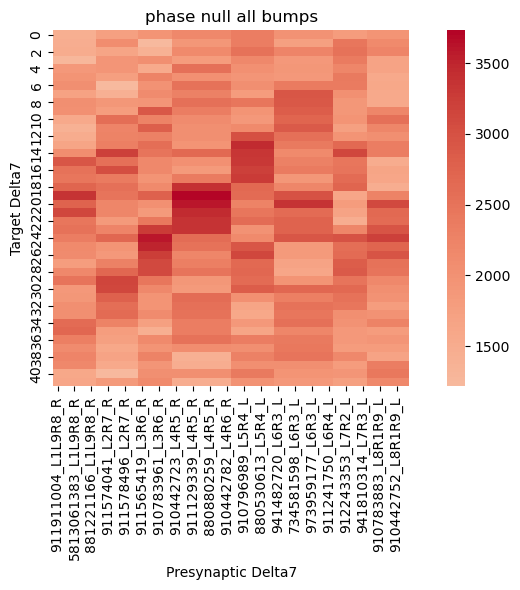

In [46]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    d7_result_bump_summary_rolled,
    cmap="coolwarm",
    center=0,
    square=True,)
plt.xlabel("Presynaptic Delta7")
plt.ylabel("Target Delta7")
plt.title("phase null all bumps")
plt.tight_layout()
plt.show()

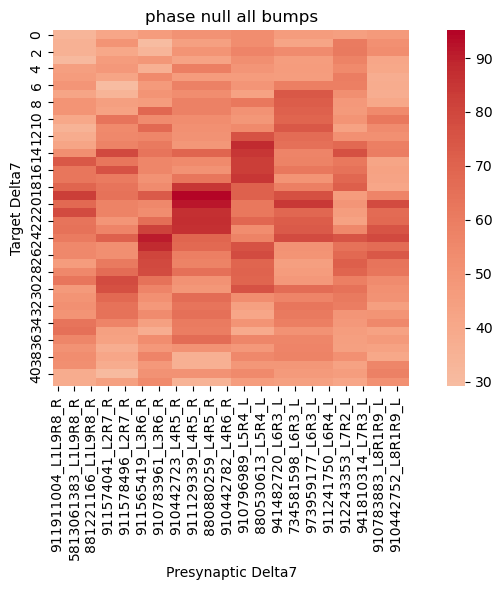

In [98]:
d7_result_bump_summary_by_synapse_rolled = glucl.roll_matrix_columns_to_center_zero(
    input_matrix=d7_result_bump_summary_by_synapse,
    relative_matrix=d7_relative_glomerulus_matrix,
)
plt.figure(figsize=(8, 6))
sns.heatmap(
    d7_result_bump_summary_by_synapse_rolled,
    cmap="coolwarm",
    center=0,
    square=True,)
plt.xlabel("Presynaptic Delta7")
plt.ylabel("Target Delta7")
plt.title("phase null all bumps")
plt.tight_layout()
plt.show()

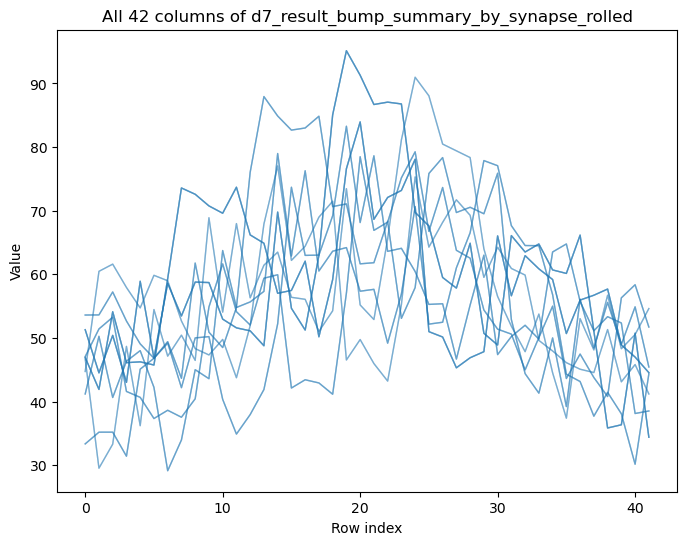

In [99]:
plt.figure(figsize=(8, 6))
x = np.arange(len(d7_result_bump_summary_by_synapse_rolled.index))

for col in d7_result_bump_summary_by_synapse_rolled.columns:
    plt.plot(
        x,
        d7_result_bump_summary_by_synapse_rolled[col],
        alpha=0.2,
        linewidth=1,
        color="tab:blue",
    )

plt.xlabel("Row index")
plt.ylabel("Value")
plt.title("All 42 columns of d7_result_bump_summary_by_synapse_rolled")
plt.show()

In [47]:
# directly multiply the glucl_scaling_values to the summary df.
synapse_count_table_add_bump_summary_glucl = (
    glucl.build_multiplied_bump_summary(
        summary_df=summary_df,
        bump_summary_df=synapse_count_table_add_bump_summary,
        divide_by=24,
    ))

synapse_count_table_add_bump_summary_all = pd.concat(
    [synapse_count_table_add_bump_summary, synapse_count_table_add_bump_summary_glucl,],
    ignore_index=True,)
synapse_count_table_add_bump_summary_all

,source,axon_4_L,axon_3_L,axon_2_L,axon_1_L,axon_0,axon_1_R,axon_2_R,axon_3_R,axon_4_R,dendrite_4_L,dendrite_3_L,dendrite_2_L,dendrite_1_L,dendrite_0,dendrite_1_R,dendrite_2_R,dendrite_3_R,dendrite_4_R
0,no_glucl_weight_added,0.0,628.361387,1591.066884,2437.655890,2772.00000,2437.655890,1591.066884,628.361387,0.0,21704.000000,18525.522789,10852.000000,3178.477211,0.0,3178.477211,10852.000000,18525.522789,21704.000000
1,multiply_percentage_total_green,0.0,628.361387,1591.066884,2437.655890,2772.00000,2437.655890,1591.066884,628.361387,0.0,4612.970484,3937.416598,2306.485242,675.553887,0.0,675.553887,2306.485242,3937.416598,4612.970484
2,multiply_percentage_total_green_divided_by_d7c...,0.0,14.504632,36.727018,56.269056,63.98681,56.269056,36.727018,14.504632,0.0,125.694355,107.286843,62.847178,18.407512,0.0,18.407512,62.847178,107.286843,125.694355


In [48]:
d7_result_bump_summary_rolled_rowmean = pd.DataFrame(
    {
        "row_mean": d7_result_bump_summary_rolled.mean(axis=1)
    }
)

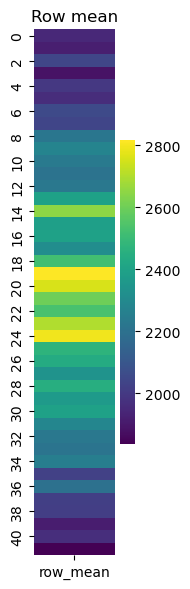

In [49]:
vmin = d7_result_bump_summary_rolled_rowmean["row_mean"].min()
vmax = d7_result_bump_summary_rolled_rowmean["row_mean"].max()

plt.figure(figsize=(2, 6))

sns.heatmap(
    d7_result_bump_summary_rolled_rowmean,
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
)

plt.title("Row mean")
plt.tight_layout()
plt.show()

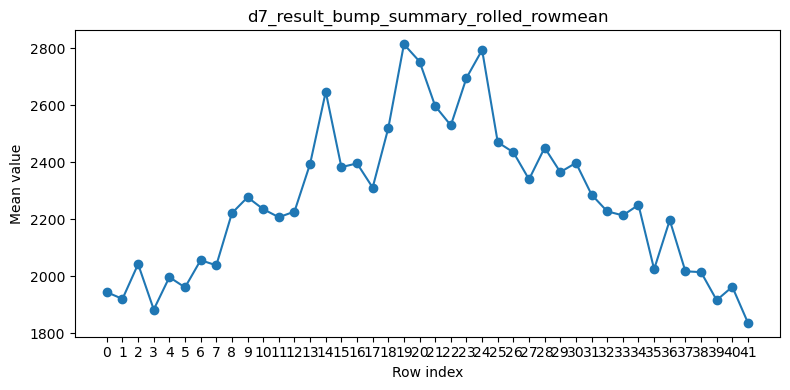

In [50]:
y = d7_result_bump_summary_rolled_rowmean["row_mean"].to_numpy()

x = np.arange(len(y))

plt.figure(figsize=(8, 4))

plt.plot(
    x,
    y,
    marker="o",
)

plt.xticks(x)

plt.xlabel("Row index")
plt.ylabel("Mean value")
plt.title("d7_result_bump_summary_rolled_rowmean")

plt.tight_layout()
plt.show()

In [51]:
# Cell 1: group the 42 row means into 8 left-glomerulus groups

grouped_bump_mean = glucl.group_rowmean_by_left_glomerulus(
    rowmean_df=d7_result_bump_summary_rolled_rowmean,
    labels=d7_relative_glomerulus_matrix.columns,
    value_col="row_mean",
)

grouped_bump_mean

,left_glomerulus,n_cells,raw_indices,x_center,bump_sum,bump_mean
0,1,5,"[0, 1, 2, 3, 4]",2.0,9784.202300,1956.840460
1,2,5,"[5, 6, 7, 8, 9]",7.0,10552.407699,2110.481540
2,3,4,"[10, 11, 12, 13]",11.5,9063.648368,2265.912092
3,4,7,"[14, 15, 16, 17, 18, 19, 20]",17.0,17826.939658,2546.705665
4,5,5,"[21, 22, 23, 24, 25]",23.0,13088.821748,2617.764350
5,6,7,"[26, 27, 28, 29, 30, 31, 32]",29.0,16503.614809,2357.659258
6,7,4,"[33, 34, 35, 36]",34.5,8684.547834,2171.136959
7,8,5,"[37, 38, 39, 40, 41]",39.0,9744.509757,1948.901951


In [93]:
# Cell 2: fit cosine to the 8 grouped means

fit_result = glucl.fit_8point_cosine_phase_only(
    grouped_bump_df=grouped_bump_mean,
    x_col="left_glomerulus",
    y_col="bump_mean",
    T=8,
)

fit_result["A"], fit_result["B"], fit_result["T"], fit_result["phi"]

(334.4311990896524, 2283.3331505106707, 8.0, 4.6614674611245555)

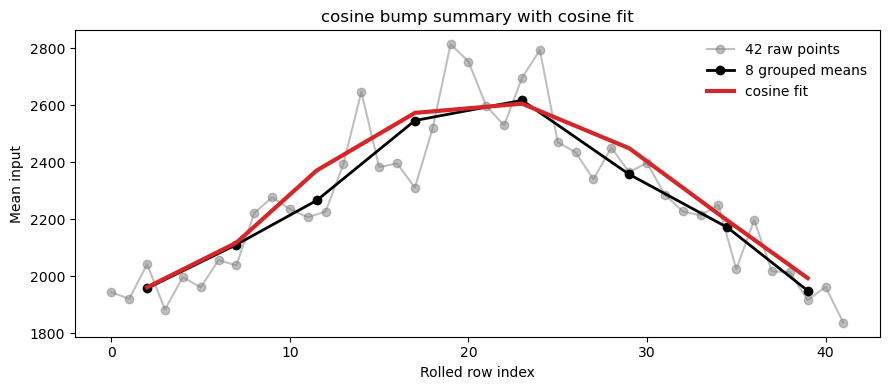

In [94]:
# Cell 3: plot 42 raw points + 8 grouped points + cosine fit

glucl.plot_raw_grouped_and_cosine_fit(
    rowmean_df=d7_result_bump_summary_rolled_rowmean,
    grouped_bump_df=grouped_bump_mean,
    fit_result=fit_result,
    value_col="row_mean",
    title="cosine bump summary with cosine fit",
    ylabel="Mean input",
)

In [54]:
fit_result = glucl.fit_8point_cosine_phase_only(
    grouped_bump_df=grouped_bump_mean,
    x_col="left_glomerulus",
    y_col="bump_mean",
    T=8,
)

In [55]:
print(
    f"curve_fit (T={fit_result['T']}): "
    f"A={fit_result['A']:.6f}, "
    f"phi={fit_result['phi']:.6f}, "
    f"B={fit_result['B']:.6f} | "
    f"R^2={fit_result['R2']:.6f}, "
    f"RMSE={fit_result['RMSE']:.6f}"
)

curve_fit (T=8.0): A=334.431199, phi=4.661467, B=2283.333151 | R^2=0.947500, RMSE=53.572779


# von mises or delta bump

In [81]:
d7_vm_bump_locations = glucl.map_relative_matrix_to_cosine_bump(
    relative_matrix=d7_relative_glomerulus_matrix,
    cos_bump_array=vm_bump,
)
d7_delta_bump_locations = glucl.map_relative_matrix_to_cosine_bump(
    relative_matrix=d7_relative_glomerulus_matrix,
    cos_bump_array=delta_bump,
)
d7_result_vm_bump_summary = (
    d7_input_matrix_glucl_receptor
    .dot(d7_vm_bump_locations)
)
d7_result_delta_bump_summary = (
    d7_input_matrix_glucl_receptor
    .dot(d7_delta_bump_locations)
)
d7_result_vm_bump_summary_rolled = glucl.roll_matrix_columns_to_center_zero(
    input_matrix=d7_result_vm_bump_summary,
    relative_matrix=d7_relative_glomerulus_matrix,
)
d7_result_delta_bump_summary_rolled = glucl.roll_matrix_columns_to_center_zero(
    input_matrix=d7_result_delta_bump_summary,
    relative_matrix=d7_relative_glomerulus_matrix,
)
d7_result_vm_bump_summary_rolled_rowmean = pd.DataFrame({"row_mean": d7_result_vm_bump_summary_rolled.mean(axis=1)})
d7_result_delta_bump_summary_rolled_rowmean = pd.DataFrame({"row_mean": d7_result_delta_bump_summary_rolled.mean(axis=1)})

grouped_bump_mean_vmbump = glucl.group_rowmean_by_left_glomerulus(
    rowmean_df=d7_result_vm_bump_summary_rolled_rowmean,
    labels=d7_relative_glomerulus_matrix.columns,
    value_col="row_mean",
)
grouped_bump_mean_deltabump = glucl.group_rowmean_by_left_glomerulus(
    rowmean_df=d7_result_delta_bump_summary_rolled_rowmean,
    labels=d7_relative_glomerulus_matrix.columns,
    value_col="row_mean",
)
fit_result_vmbump = glucl.fit_8point_cosine_phase_only(
    grouped_bump_df=grouped_bump_mean_vmbump,
    x_col="left_glomerulus",
    y_col="bump_mean",
    T=8,
)
fit_result_deltabump = glucl.fit_8point_cosine_phase_only(
    grouped_bump_df=grouped_bump_mean_deltabump,
    x_col="left_glomerulus",
    y_col="bump_mean",
    T=8,
)

/Users/fisherguest/Documents/Projects/connectome_analysis_fisherlab/send_to_fisherlabgithub/library/lib_glucl_drive.py:991: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  out = out.applymap(lambda x: relative_to_bump.get(int(x), np.nan))


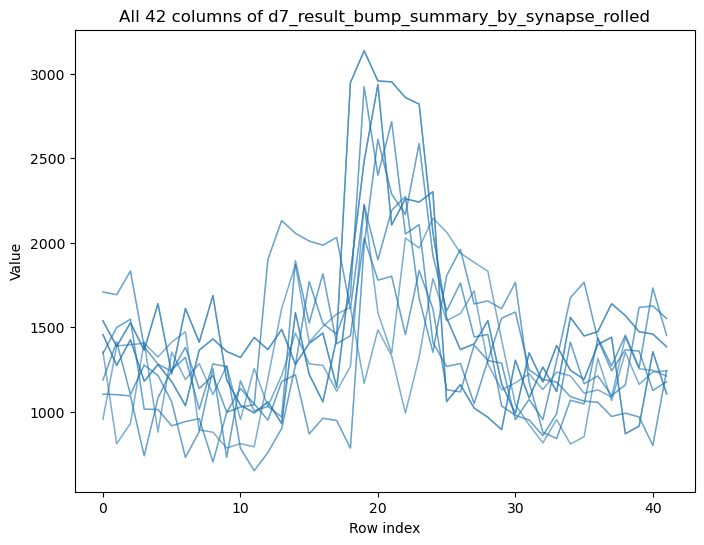

In [82]:
plt.figure(figsize=(8, 6))
x = np.arange(len(d7_result_vm_bump_summary_rolled.index))

for col in d7_result_vm_bump_summary_rolled.columns:
    plt.plot(
        x,
        d7_result_vm_bump_summary_rolled[col],
        alpha=0.2,
        linewidth=1,
        color="tab:blue",
    )

plt.xlabel("Row index")
plt.ylabel("Value")
plt.title("All 42 columns of d7_result_bump_summary_by_synapse_rolled")
plt.show()

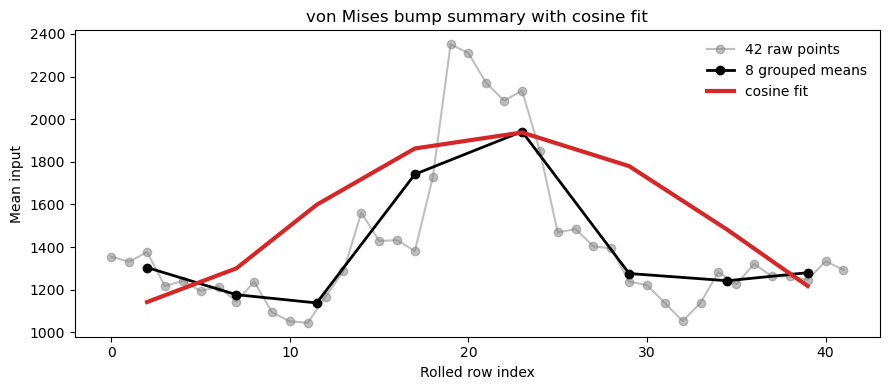

In [91]:
glucl.plot_raw_grouped_and_cosine_fit(
    rowmean_df=d7_result_vm_bump_summary_rolled_rowmean,
    grouped_bump_df=grouped_bump_mean_vmbump,
    fit_result=fit_result_vmbump,
    value_col="row_mean",
    title="von Mises bump summary with cosine fit",
    ylabel="Mean input",
)

In [86]:
fit_result = glucl.fit_8point_cosine_phase_only(
    grouped_bump_df=grouped_bump_mean_vmbump,
    x_col="left_glomerulus",
    y_col="bump_mean",
    T=8,
)
print(
    f"curve_fit (T={fit_result['T']}): "
    f"A={fit_result['A']:.6f}, "
    f"phi={fit_result['phi']:.6f}, "
    f"B={fit_result['B']:.6f} | "
    f"R^2={fit_result['R2']:.6f}, "
    f"RMSE={fit_result['RMSE']:.6f}"
)

curve_fit (T=8.0): A=401.766950, phi=4.814009, B=1540.165026 | R^2=0.014437, RMSE=269.849799


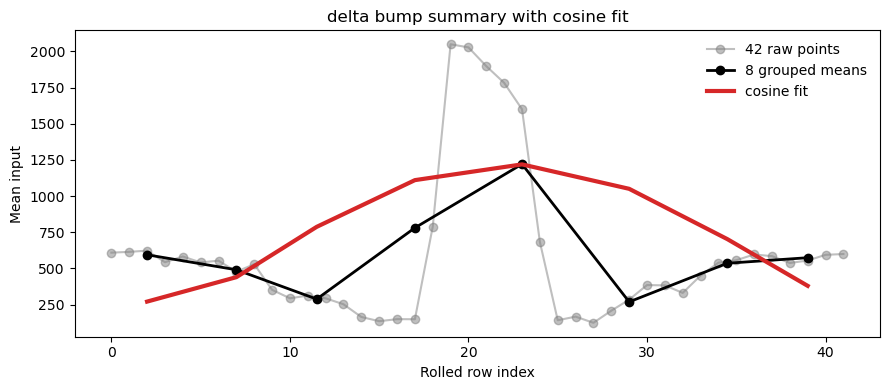

In [90]:
glucl.plot_raw_grouped_and_cosine_fit(
    rowmean_df=d7_result_delta_bump_summary_rolled_rowmean,
    grouped_bump_df=grouped_bump_mean_deltabump,
    fit_result=fit_result_deltabump,
    value_col="row_mean",
    title="delta bump summary with cosine fit",
    ylabel="Mean input",
)

In [87]:
fit_result = glucl.fit_8point_cosine_phase_only(
    grouped_bump_df=grouped_bump_mean_deltabump,
    x_col="left_glomerulus",
    y_col="bump_mean",
    T=8,
)
print(
    f"curve_fit (T={fit_result['T']}): "
    f"A={fit_result['A']:.6f}, "
    f"phi={fit_result['phi']:.6f}, "
    f"B={fit_result['B']:.6f} | "
    f"R^2={fit_result['R2']:.6f}, "
    f"RMSE={fit_result['RMSE']:.6f}"
)

curve_fit (T=8.0): A=476.036745, phi=4.886327, B=744.905041 | R^2=-0.778761, RMSE=377.719827


# check whether the roll function works...

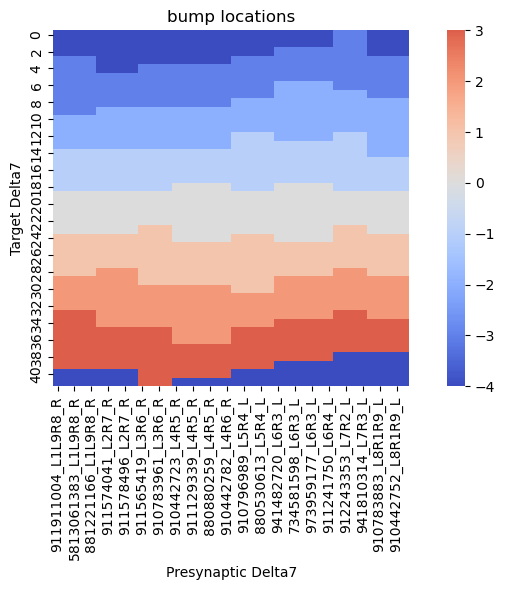

In [56]:
d7_relative_glomerulus_matrix_rolled = (
    glucl.roll_matrix_columns_to_center_zero(
        input_matrix=d7_relative_glomerulus_matrix,
        relative_matrix=d7_relative_glomerulus_matrix,
    )
)
plt.figure(figsize=(8, 6))
sns.heatmap(
    d7_relative_glomerulus_matrix_rolled,
    cmap="coolwarm",
    center=0,
    square=True,)
plt.xlabel("Presynaptic Delta7")
plt.ylabel("Target Delta7")
plt.title("bump locations")
plt.tight_layout()
plt.show()

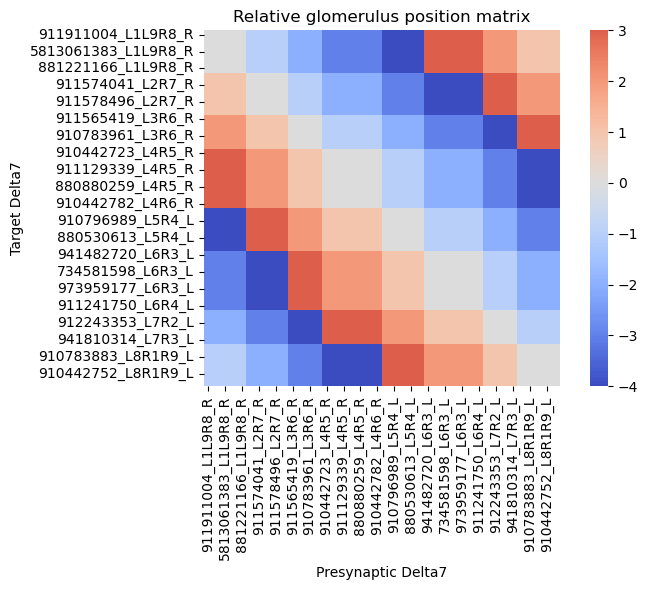

In [57]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    d7_relative_glomerulus_matrix,
    cmap="coolwarm",
    center=0,
    square=True,)
plt.xlabel("Presynaptic Delta7")
plt.ylabel("Target Delta7")
plt.title("Relative glomerulus position matrix")
plt.tight_layout()
plt.show()

more:
1. compare with glucl and without glucl, see if the fit is the same (R^2)
2. inputp a von mises bump, see if run through the matrix will output a bump very similar to a cosine bump (meaning the kappa in the von mises is at a value making the shape near cosine)

# YF version

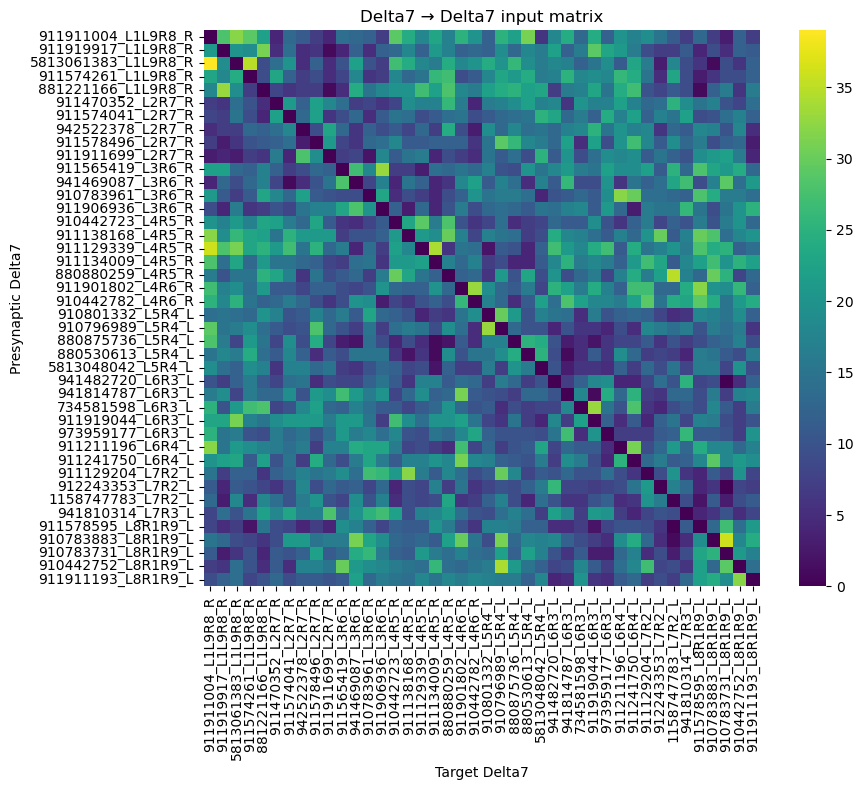

In [101]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    d7_input_matrix,
    cmap="viridis",
    square=True,)

plt.xlabel("Target Delta7")
plt.ylabel("Presynaptic Delta7")
plt.title("Delta7 → Delta7 input matrix")
plt.tight_layout()
plt.show()

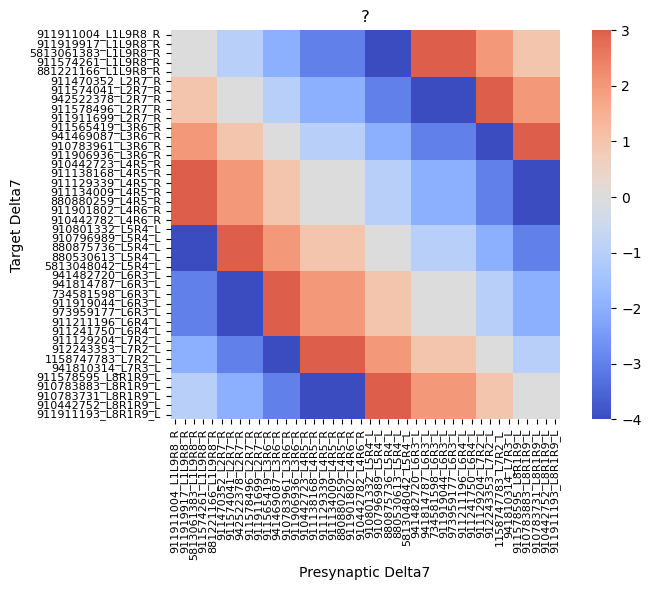

In [102]:
glucl.plot_matrix_heatmap(
    d7_relative_glomerulus_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="?",
)

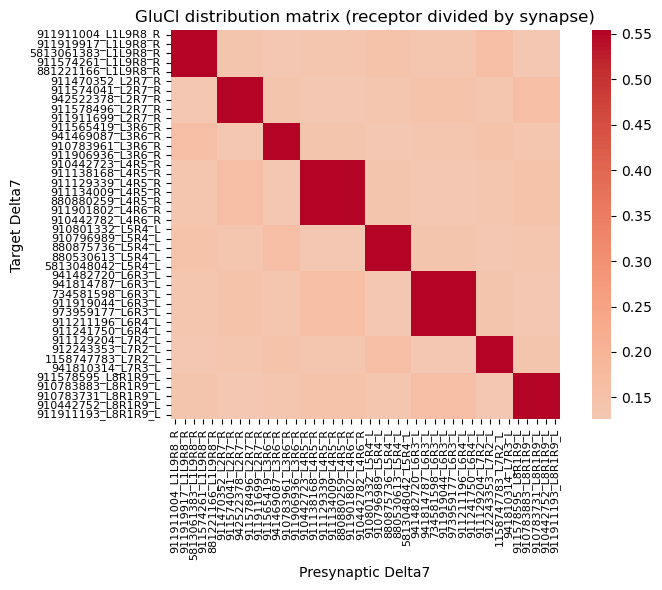

In [103]:
glucl.plot_matrix_heatmap(
    d7_glucl_matrix_d7norm,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="GluCl distribution matrix (receptor divided by synapse)",
)

In [104]:
d7_glucl_matrix_d7norm_axon = (
    d7_glucl_matrix_d7norm.where(
        d7_relative_glomerulus_matrix == 0,
        0,
    )
)

d7_glucl_matrix_d7norm_dendrite = (
    d7_glucl_matrix_d7norm.where(
        d7_relative_glomerulus_matrix != 0,
        0,
    )
)

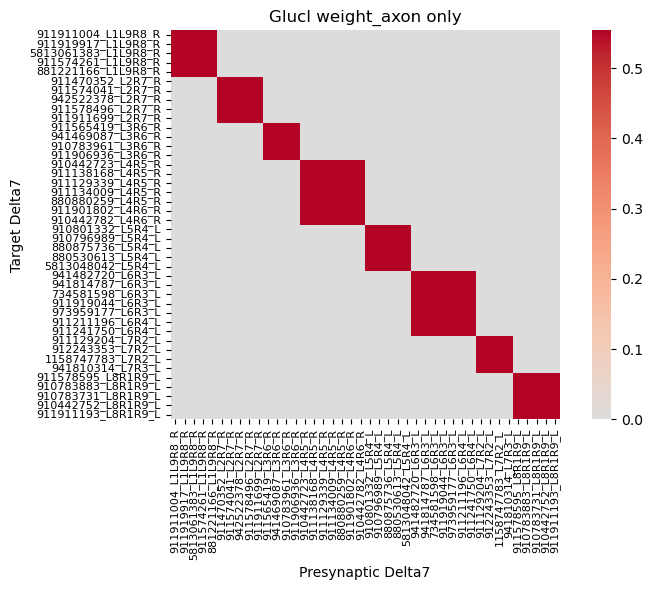

In [105]:
glucl.plot_matrix_heatmap(
    d7_glucl_matrix_d7norm_axon,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="Glucl weight_axon only",
)

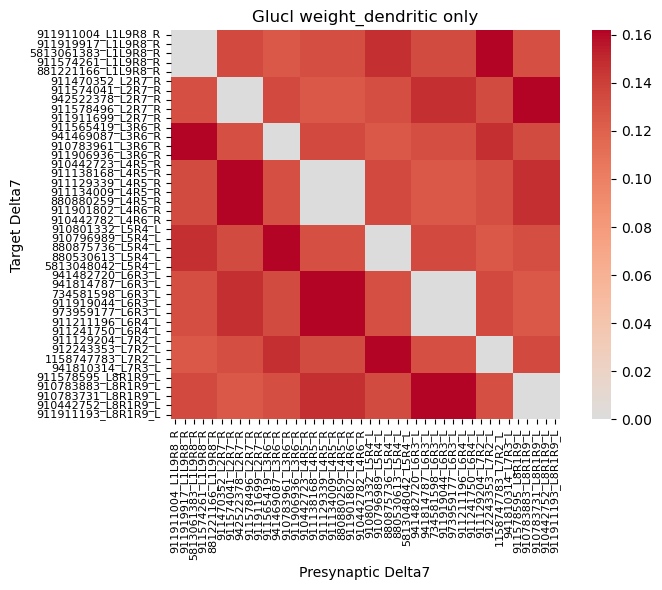

In [106]:
glucl.plot_matrix_heatmap(
    d7_glucl_matrix_d7norm_dendrite,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="Glucl weight_dendritic only",
)

In [107]:
chloride_influx_axon = d7_input_matrix * d7_glucl_matrix_d7norm_axon
chloride_influx_dendrite = d7_input_matrix * d7_glucl_matrix_d7norm_dendrite

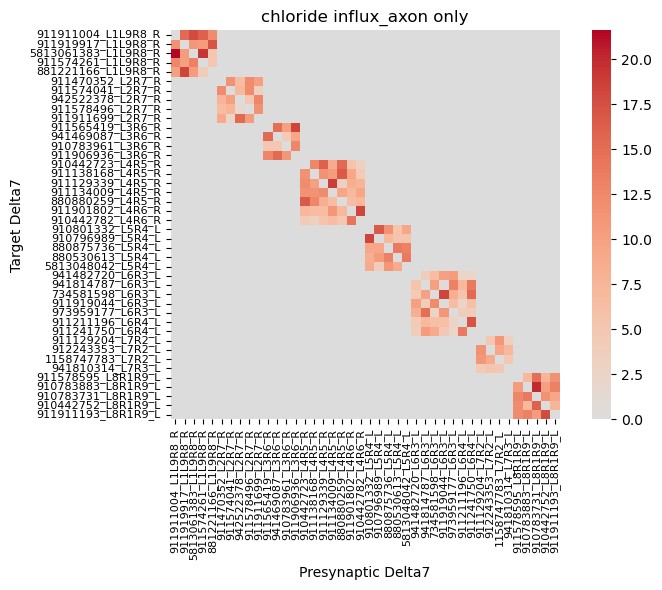

In [108]:
glucl.plot_matrix_heatmap(
    chloride_influx_axon,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="chloride influx_axon only",
)

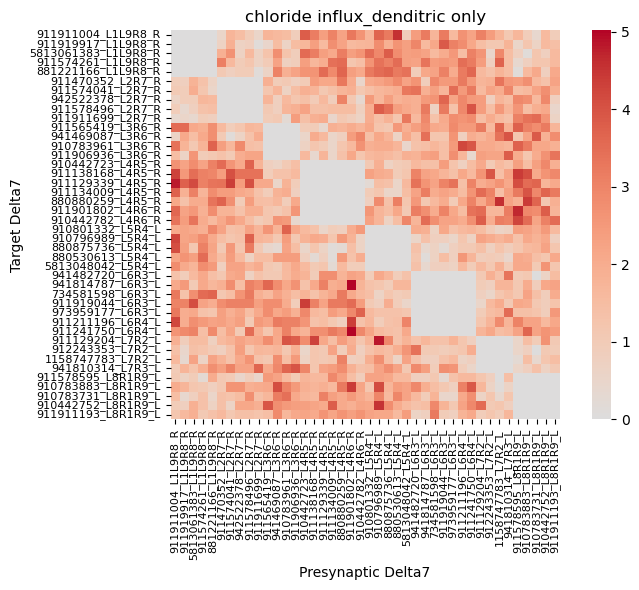

In [109]:
glucl.plot_matrix_heatmap(
    chloride_influx_dendrite,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="chloride influx_denditric only",
)

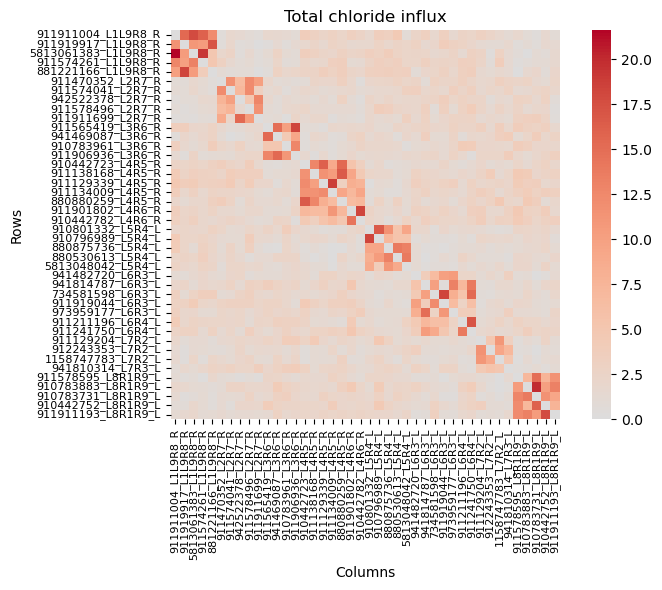

In [110]:
chloride_influx_total = ( chloride_influx_axon + chloride_influx_dendrite )

glucl.plot_matrix_heatmap(
    chloride_influx_total,
    cmap="coolwarm",
    center=0,
    figsize=(8, 6),
    title="Total chloride influx",
)

In [111]:
d7_bump_locations_glomlabels = d7_bump_locations.copy()

new_labels = [
    str(x).split("_", 1)[1][:2]
    for x in d7_bump_locations.index
]

d7_bump_locations_glomlabels.index = new_labels
d7_bump_locations_glomlabels.columns = new_labels


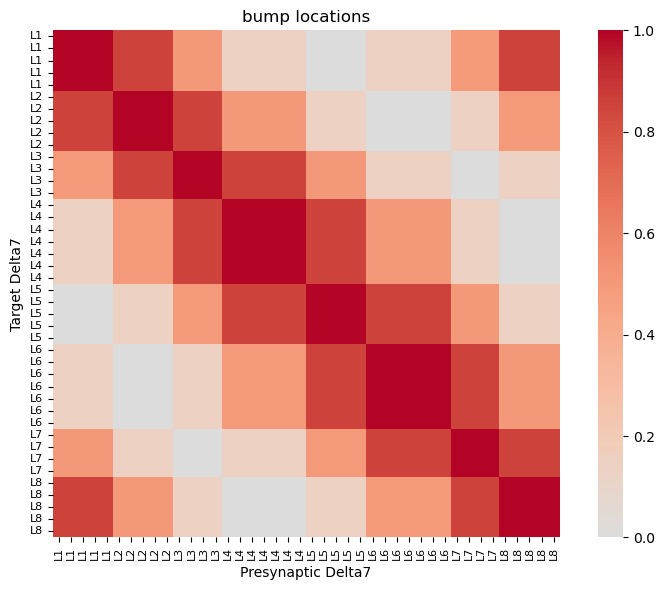

In [112]:
glucl.plot_matrix_heatmap(
    d7_bump_locations_glomlabels,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="bump locations",
)

In [113]:
keep_cols = ~d7_bump_locations_glomlabels.columns.duplicated(keep="first")

d7_bump_locations_glomlabels_condensed = (
    d7_bump_locations_glomlabels
    .loc[:, keep_cols]
)

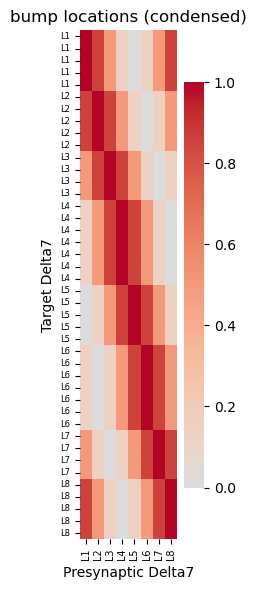

In [114]:
glucl.plot_matrix_heatmap(
    d7_bump_locations_glomlabels_condensed,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(2, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="bump locations (condensed)",
    xtick_fontsize=7,
    ytick_fontsize=6,
)

explanation for the below cell: first, outside loop through all columns in inhibition_matrix, second, inside loop through all columns in bump_matrix_colcondensed.

For the first column in inhibition_matrix, it will first multiply with the first column in bump_matrix_colcondensed (so neuron 911911004_L1L9R8_R in either axon-only matrix or dendrite-only matrix multiply the bump with its peak at glomerulus 1) **element-wise** and obtain 42 numbers. Then sum these 42 numbers. Then multiply this column in inhibition_matrix with the second column in bump_matrix_colcondensed and obtain the second sum. In this way there will be 8 sums, and these 8 numbers are stored as **row** one (for neuron 911911004_L1L9R8_R) in the the resulting matrix.
Then loop to the second column in inhibition_matrix and obtain the second **row** in the resulting matrix.

In this way, if inhibition_matrix is chloride_influx_axon, which only includes synapse count with glucl weight for axonal glomeruli, the resulting matrix (axo_axonal_cl_inhibition) tells you that for each cell, what are the chloride inhibition its one axonal glomerulus receive when the bump peak is at glomerulus 1...glomerulus 8. If inhibition_matrix is axo_dendritic_cl_inhibition, then the resulting matrix (axo_dendritic_cl_inhibition) tells you that for each cell, what are the chloride inhibtion all of its 7 dendritic glomeruli recieve when the bump peak is at glomerulus 1...glomerulus 8.

In [115]:
axo_axonal_cl_inhibition = glucl.project_inhibition_onto_bump_columns(
    inhibition_matrix=chloride_influx_axon,
    bump_matrix_colcondensed=d7_bump_locations_glomlabels_condensed,
)

something is wrong here...why is each curve in axon symmetric? the dendritic ones aren't...

A: this is correct. axon curves is made from using the same number multiply the cosine bump. because the bump is symmetric, the resulting curve will be symmetric. This is different from dendritic because the numbers getting multiplied at a given bumpm position is different.

In [116]:
axo_axonal_cl_inhibition.head()

,L1,L2,L3,L4,L5,L6,L7,L8
source,,,,,,,,
911911004_L1L9R8_R,55.953833,47.759584,27.976917,8.194249,0.0,8.194249,27.976917,47.759584
911919917_L1L9R8_R,54.291838,46.340983,27.145919,7.950856,0.0,7.950856,27.145919,46.340983
5813061383_L1L9R8_R,52.629843,44.922381,26.314922,7.707462,0.0,7.707462,26.314922,44.922381
911574261_L1L9R8_R,49.859852,42.558045,24.929926,7.301806,0.0,7.301806,24.929926,42.558045
881221166_L1L9R8_R,39.333883,33.573569,19.666941,5.760314,0.0,5.760314,19.666941,33.573569


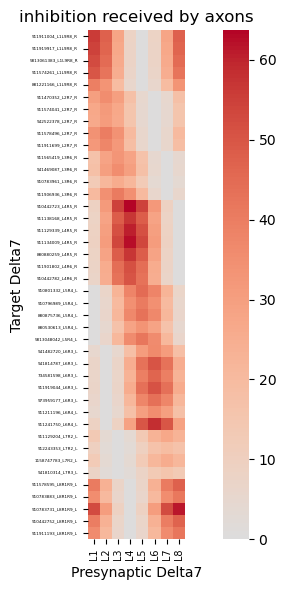

In [117]:
glucl.plot_matrix_heatmap(
    axo_axonal_cl_inhibition,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="inhibition received by axons",
    xtick_fontsize=7,
    ytick_fontsize=3,
)

Logically the same as making axo_axonal_cl_inhibition. Since at a given bump peak location, after multiplying the inhibition_matrix with bump_matrix_colcondensed element-wisely, I summed the 42 numbers, the resulting matrix means when the bump is at a given location, what is the total dendritic chloride inhibition the cell receives.

To make sense of the x axis (bump peak glomerular position), I can still think of it as "when the bump peak is at this amount of glomerular distance to the axonal glomerulus of this cell, what is the total dendritic chloride inhibition this cell receives?".

In [118]:
axo_dendritic_cl_inhibition = glucl.project_inhibition_onto_bump_columns(
    inhibition_matrix=chloride_influx_dendrite,
    bump_matrix_colcondensed=d7_bump_locations_glomlabels_condensed,
)

In [134]:
axo_dendritic_cl_inhibition.head()

,L1,L2,L3,L4,L5,L6,L7,L8
source,,,,,,,,
911911004_L1L9R8_R,23.092521,30.445072,45.008579,58.251938,62.417367,55.064816,40.501309,27.257951
911919917_L1L9R8_R,17.847944,23.475526,33.772514,42.707074,45.045461,39.417880,29.120892,20.186332
5813061383_L1L9R8_R,23.291906,28.517320,38.934102,48.440241,51.467172,46.241757,35.824976,26.318836
911574261_L1L9R8_R,20.458732,25.623555,35.988534,45.482003,48.542818,43.377995,33.013016,23.519547
881221166_L1L9R8_R,22.544658,29.174278,40.475515,49.828257,51.753794,45.124173,33.822937,24.470195


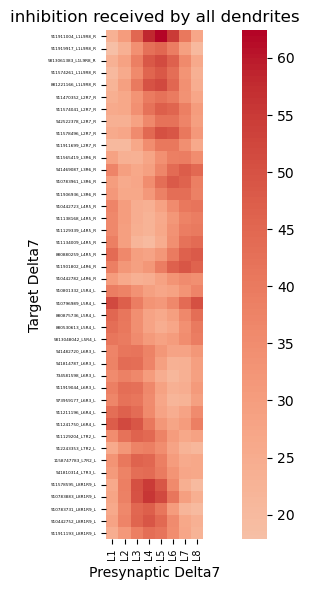

In [120]:
glucl.plot_matrix_heatmap(
    axo_dendritic_cl_inhibition,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="inhibition received by all dendrites",
    xtick_fontsize=7,
    ytick_fontsize=3,
)

In [121]:
axo_axonal_cl_inhibition_rolled = glucl.roll_each_row_to_center_glomerulus(
    axo_axonal_cl_inhibition,
    target_idx=4,
)
axo_dendritic_cl_inhibition_rolled = glucl.roll_each_row_to_center_glomerulus(
    axo_dendritic_cl_inhibition,
    target_idx=4,
)

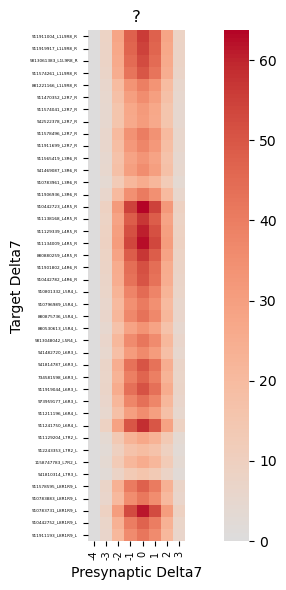

In [122]:
glucl.plot_matrix_heatmap(
    axo_axonal_cl_inhibition_rolled,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="?",
    xtick_fontsize=7,
    ytick_fontsize=3,
)

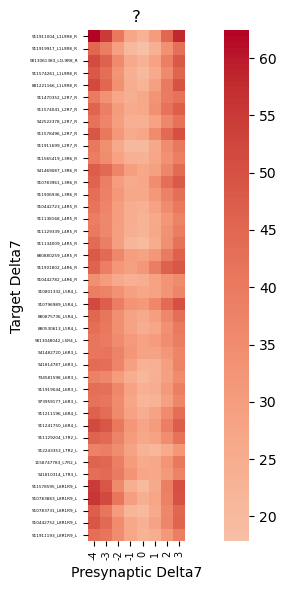

In [123]:
glucl.plot_matrix_heatmap(
    axo_dendritic_cl_inhibition_rolled,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="?",
    xtick_fontsize=7,
    ytick_fontsize=3,
)

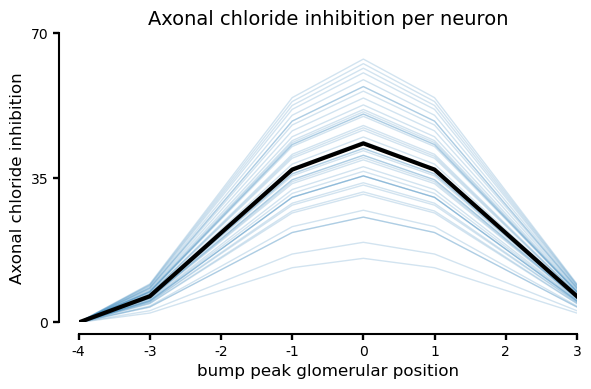

In [195]:
glucl.plot_each_row_as_line(
    axo_axonal_cl_inhibition_rolled,
    color="tab:blue",
    alpha=0.2,
    mean_color="black",
    figsize=(6, 4),
    ylabel="Axonal chloride inhibition",
    xlabel="bump peak glomerular position",
    title="Axonal chloride inhibition per neuron",
    ytick_decimals=0,
    y_min_mode="data",
    tick_length=4,
    tick_width=1.7,
    axis_linewidth=1.5,
    title_fontsize=14,
    axis_label_size=12,
    tick_label_size=10,
    legend_fontsize=10,
)

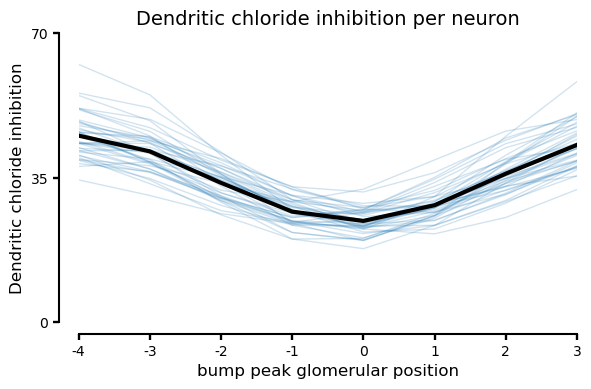

In [203]:
glucl.plot_each_row_as_line(
    axo_dendritic_cl_inhibition_rolled,
    color="tab:blue",
    alpha=0.2,
    mean_color="black",
    figsize=(6, 4),
    ylabel="Dendritic chloride inhibition",
    xlabel="bump peak glomerular position",
    title="Dendritic chloride inhibition per neuron",
    ytick_decimals=0,
    y_min_mode="zero",      # of 'data'
    tick_length=4,
    tick_width=1.7,
    axis_linewidth=1.5,
    title_fontsize=14,
    axis_label_size=12,
    tick_label_size=10,
    legend_fontsize=10,
    y_max_pad_frac=0.05,
)

In [193]:
importlib.reload(glucl)

<module 'lib_glucl_drive' from '/Users/fisherguest/Documents/Projects/connectome_analysis_fisherlab/send_to_fisherlabgithub/library/lib_glucl_drive.py'>

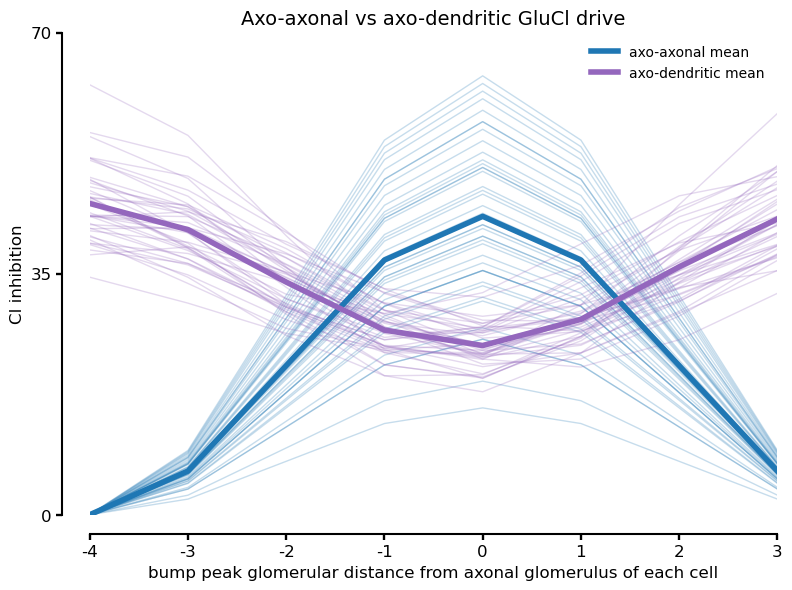

In [197]:
glucl.plot_two_dfs_each_row_as_line(
    axo_axonal_cl_inhibition_rolled,
    axo_dendritic_cl_inhibition_rolled,
    figsize=(8, 6),
    title_fontsize=14,
    axis_label_size=12,
    tick_label_size=12,
    legend_fontsize=10,
    df1_color="tab:blue",
    df2_color="tab:purple",
    df1_label="axo-axonal mean",
    df2_label="axo-dendritic mean",
    alpha=0.25,
    linewidth=1,
    mean_linewidth=4,
    marker="o",
    marker_size=0,
    xlabel="bump peak glomerular distance from axonal glomerulus of each cell",
    ylabel="Cl inhibition",
    title="Axo-axonal vs axo-dendritic GluCl drive",
    y_min_mode="zero",
    ytick_decimals=0,
    tick_length=4,
    tick_width=1.7,
    axis_linewidth=1.5,
)

In [135]:
combined_cl_inhibition_rolled = (
    axo_axonal_cl_inhibition_rolled +
    axo_dendritic_cl_inhibition_rolled)

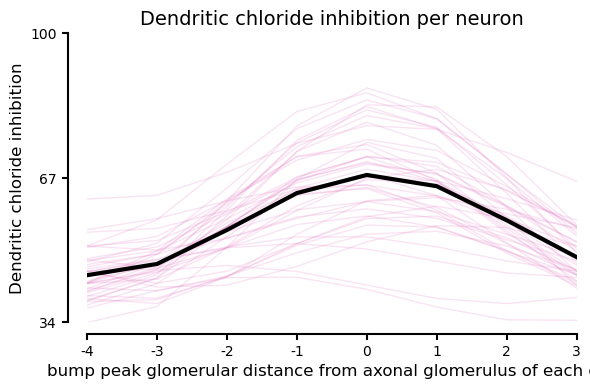

In [202]:
glucl.plot_each_row_as_line(
    combined_cl_inhibition_rolled,
    color="tab:pink",
    alpha=0.2,
    mean_color="black",
    figsize=(6, 4),
    ylabel="Dendritic chloride inhibition",
    xlabel="bump peak glomerular distance from axonal glomerulus of each cell",
    title="Dendritic chloride inhibition per neuron",
    y_min_mode="data",
    ytick_decimals=0,
)

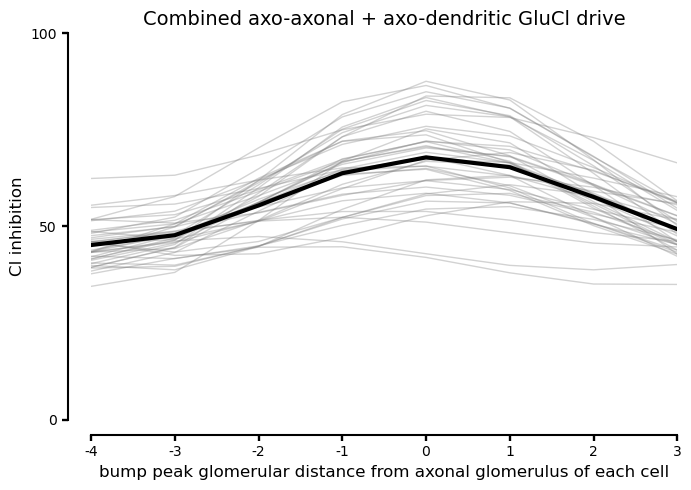

In [201]:
glucl.plot_each_row_as_line(
    combined_cl_inhibition_rolled,
    color="gray",
    alpha=0.35,
    linewidth=1,
    mean_color="black",
    mean_linewidth=3,
    marker="o",
    marker_size=0,
    xlabel="bump peak glomerular distance from axonal glomerulus of each cell",
    ylabel="Cl inhibition",
    title="Combined axo-axonal + axo-dendritic GluCl drive",
    y_min_mode="zero",   # bottom y tick is 0
    ytick_decimals=0,
    tick_length=4,
    tick_width=1.7,
    axis_linewidth=1.5,
    title_fontsize=14,
    axis_label_size=12,
    tick_label_size=10,
    legend_fontsize=10,
)

In [207]:
axo_axonal_cl_inhibition_rolled2 = axo_axonal_cl_inhibition_rolled.copy()
axo_axonal_cl_inhibition_rolled2 = axo_axonal_cl_inhibition_rolled2.iloc[
    :,
    np.roll(np.arange(axo_axonal_cl_inhibition_rolled2.shape[1]), -4)]

axo_dendritic_cl_inhibition_rolled2 = axo_dendritic_cl_inhibition_rolled.copy()
axo_dendritic_cl_inhibition_rolled2 = axo_dendritic_cl_inhibition_rolled2.iloc[
    :,
    np.roll(np.arange(axo_dendritic_cl_inhibition_rolled2.shape[1]), -4)]

combined_cl_inhibition_rolled2 = combined_cl_inhibition_rolled.copy()
combined_cl_inhibition_rolled2 = combined_cl_inhibition_rolled2.iloc[
    :,
    np.roll(np.arange(combined_cl_inhibition_rolled2.shape[1]), -4)]

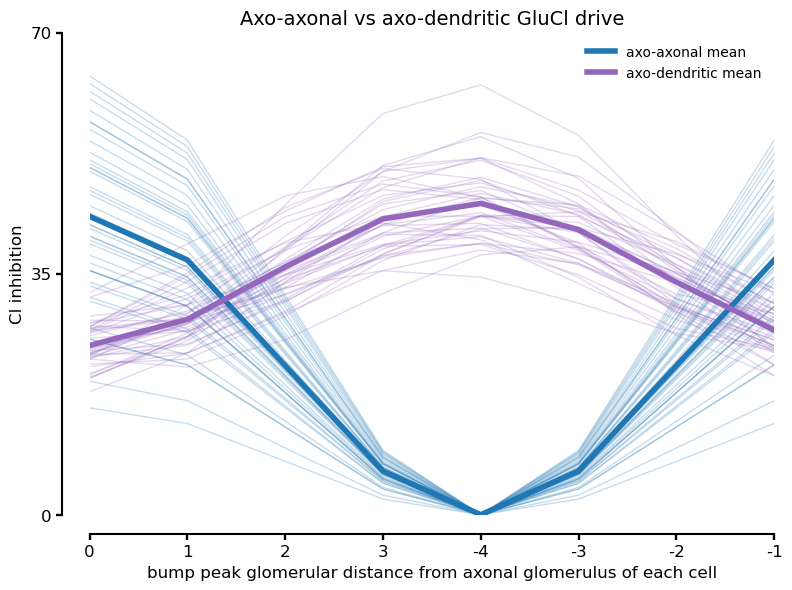

In [206]:
glucl.plot_two_dfs_each_row_as_line(
    axo_axonal_cl_inhibition_rolled2,
    axo_dendritic_cl_inhibition_rolled2,
    figsize=(8, 6),
    title_fontsize=14,
    axis_label_size=12,
    tick_label_size=12,
    legend_fontsize=10,
    df1_color="tab:blue",
    df2_color="tab:purple",
    df1_label="axo-axonal mean",
    df2_label="axo-dendritic mean",
    alpha=0.25,
    linewidth=1,
    mean_linewidth=4,
    marker="o",
    marker_size=0,
    xlabel="bump peak glomerular distance from axonal glomerulus of each cell",
    ylabel="Cl inhibition",
    title="Axo-axonal vs axo-dendritic GluCl drive",
    y_min_mode="zero",
    ytick_decimals=0,
    tick_length=4,
    tick_width=1.7,
    axis_linewidth=1.5,
)

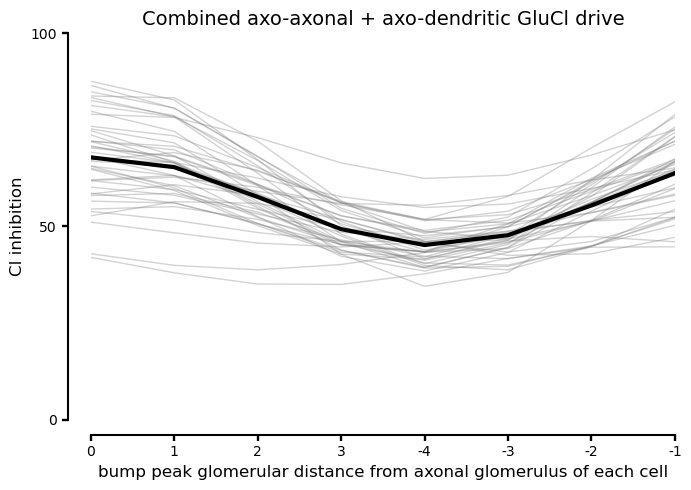

In [208]:
glucl.plot_each_row_as_line(
    combined_cl_inhibition_rolled2,
    color="gray",
    alpha=0.35,
    linewidth=1,
    mean_color="black",
    mean_linewidth=3,
    marker="o",
    marker_size=0,
    xlabel="bump peak glomerular distance from axonal glomerulus of each cell",
    ylabel="Cl inhibition",
    title="Combined axo-axonal + axo-dendritic GluCl drive",
    y_min_mode="zero",   # bottom y tick is 0
    ytick_decimals=0,
    tick_length=4,
    tick_width=1.7,
    axis_linewidth=1.5,
    title_fontsize=14,
    axis_label_size=12,
    tick_label_size=10,
    legend_fontsize=10,
)

In [127]:
axo_dendritic_cl_inhibition.index

Index(['911911004_L1L9R8_R', '911919917_L1L9R8_R', '5813061383_L1L9R8_R',
       '911574261_L1L9R8_R', '881221166_L1L9R8_R', '911470352_L2R7_R',
       '911574041_L2R7_R', '942522378_L2R7_R', '911578496_L2R7_R',
       '911911699_L2R7_R', '911565419_L3R6_R', '941469087_L3R6_R',
       '910783961_L3R6_R', '911906936_L3R6_R', '910442723_L4R5_R',
       '911138168_L4R5_R', '911129339_L4R5_R', '911134009_L4R5_R',
       '880880259_L4R5_R', '911901802_L4R6_R', '910442782_L4R6_R',
       '910801332_L5R4_L', '910796989_L5R4_L', '880875736_L5R4_L',
       '880530613_L5R4_L', '5813048042_L5R4_L', '941482720_L6R3_L',
       '941814787_L6R3_L', '734581598_L6R3_L', '911919044_L6R3_L',
       '973959177_L6R3_L', '911211196_L6R4_L', '911241750_L6R4_L',
       '911129204_L7R2_L', '912243353_L7R2_L', '1158747783_L7R2_L',
       '941810314_L7R3_L', '911578595_L8R1R9_L', '910783883_L8R1R9_L',
       '910783731_L8R1R9_L', '910442752_L8R1R9_L', '911911193_L8R1R9_L'],
      dtype='object', name='source')

In [128]:
axo_axonal_cl_inhibition_rolled.loc['911129204_L7R2_L']

-4     0.000000
-3     3.975428
-2    13.572960
-1    23.170491
 0    27.145919
 1    23.170491
 2    13.572960
 3     3.975428
Name: 911129204_L7R2_L, dtype: float64

In [129]:
axo_dendritic_cl_inhibition_rolled.loc["911129204_L7R2_L"]

-4    46.109090
-3    44.388793
-2    38.000663
-1    30.686779
 0    26.731515
 1    28.451812
 2    34.839943
 3    42.153827
Name: 911129204_L7R2_L, dtype: float64

glucl.plot_each_cell_two_lines(
    df1=axo_axonal_cl_inhibition_rolled,
    df2=axo_dendritic_cl_inhibition_rolled,
    df1_color="tab:blue",
    df2_color="purple",
    df1_label="axonal",
    df2_label="dendritic",
    ylabel="Chloride inhibition",
    title_prefix="Cell: ",
)

In [ ]:
importlib.reload(glucl)

# draft (confirming the functions work as they should)

1. roll_matrix_columns_to_center_zero

In [ ]:
d7_relative_glomerulus_matrix.columns

In [ ]:
rel_col = d7_relative_glomerulus_matrix['911911004_L1L9R8_R'].to_numpy()
rel_col

In [ ]:
zero_value=0

In [ ]:
zero_positions = np.where(rel_col == zero_value)[0]
zero_positions

In [ ]:
chosen_zero_pos = zero_positions[len(zero_positions) // 2]
chosen_zero_pos

In [ ]:
center_idx = len(d7_relative_glomerulus_matrix)//2
center_idx

In [ ]:
shift = center_idx - chosen_zero_pos
shift

In [ ]:
rel_col

In [ ]:
column_tep = d7_relative_glomerulus_matrix['911911004_L1L9R8_R']
column_col = np.roll(column_tep.to_numpy(), shift,)
column_col

2. project_inhibition_onto_bump_columns

In [259]:
a= chloride_influx_axon['911911004_L1L9R8_R'].to_numpy()
a

array([ 0.        , 11.63396538, 21.6059357 , 12.74196208,  9.97197032,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ])

In [260]:
b=d7_bump_locations_glomlabels_condensed['L1'].to_numpy()
b

array([1.        , 1.        , 1.        , 1.        , 1.        ,
       0.85355339, 0.85355339, 0.85355339, 0.85355339, 0.85355339,
       0.5       , 0.5       , 0.5       , 0.5       , 0.14644661,
       0.14644661, 0.14644661, 0.14644661, 0.14644661, 0.14644661,
       0.14644661, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.14644661, 0.14644661, 0.14644661, 0.14644661,
       0.14644661, 0.14644661, 0.14644661, 0.5       , 0.5       ,
       0.5       , 0.5       , 0.85355339, 0.85355339, 0.85355339,
       0.85355339, 0.85355339])

In [ ]:
c=np.nansum(a*b)
c